In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"

fig_num = 4 # change this to the figure number
analysis_name = "hpc_DECODING" # change this to the subfolder it should save to

subject = "Wallie"
date = "20220912"
nwb_file_name = f"{subject}{date}_.nwb"
epoch_interval = "10_lineartrack"
key = {"nwb_file_name": nwb_file_name,}

from spyglass.common import PositionIntervalMap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pos_interval = (PositionIntervalMap() &{**key, "interval_list_name": epoch_interval}).fetch1("position_interval_name")

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-09-17 07:50:39,913][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


In [2]:
from spyglass.decoding.v1.c3po import Model

# model_key = {**key, "model_name":"wallie_linear_dim20_noSmooth_v0"}

# model_key = {**key, 'model_name': 'wallie_linear_dim20_10Smooth_v0'}

model_key = {
    **key,
    # 'model_name': 'wallie_linear_dim20_10Smooth_v0',
    "model_name":"wallie_linear_dim20_noSmooth_v0",
    # "training_params_name":"wallie_20_dim_v0",
    "marks_group_name":"10_lineartrack_wf_norm1000"
    # "model_name":"wallie_dim20_HYBRID_10Smooth_v0",
}


analysis = (Model & model_key).fetch_c3po_analysis(checkpoint = None)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

from c3po.analysis.analysis import figure_directory
from pathlib import Path
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{epoch_interval}_{model_key['model_name']}"
fig_dir.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/sambray/.local/lib/python3.10/site-packages/traitlets/

x shape (1, 5)


2026-09-17 07:51:04.941527: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-17 07:51:06.559192: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceM

# Load data

### position

In [3]:
from utils.load_hpc_data import load_position_data

pos_data = load_position_data(nwb_file_name, epoch_interval)

pos_df = pos_data["pos_df"]
pos_times = pos_data["pos_times"]

pos = pos_data["pos"]
vel = pos_data["vel"]
all_running_intervals = pos_data["all_running_intervals"]
left_running_intervals = pos_data["left_running_intervals"]
right_running_intervals = pos_data["right_running_intervals"]


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

### LFP

In [4]:
from utils.load_hpc_data import load_lfp_data

lfp_data = load_lfp_data(nwb_file_name, epoch_interval)
theta_phase_df = lfp_data["theta_phase_df"]
fg_phase_df = lfp_data["fg_phase_df"]
sg_phase_df = lfp_data["sg_phase_df"]


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

### SortedData

In [5]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

spikes_key = {
    **key,
    "sorted_spikes_group_name": epoch_interval,
}
SortedSpikesGroup() & spikes_key
spikes_list, unit_ids = (SortedSpikesGroup() & spikes_key).fetch_spike_data(
    spikes_key, return_unit_ids=True
)

[07:52:10][WARNING] Spyglass: Missing code for CurationV2
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-pa

### Ripples

In [6]:
from spyglass.ripple.v1 import RippleTimesV1, RippleLFPSelection

ripple_df = (
    RippleTimesV1()
    & key
    & f"target_interval_list_name LIKE '%{pos_interval}%'"
).fetch1_dataframe()
ripple_intervals = ripple_df[["start_time", "end_time"]].values

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

In [ ]:
from spyglass.lfp.analysis.v1 import LFPBandV1
rip_q = RippleTimesV1() & key & f"target_interval_list_name LIKE '%{pos_interval}%'"
query = LFPBandV1() & rip_q.proj()
ref_ind = 12
band_obj = query.fetch_nwb()[0]["lfp_band"]
rip_phase_df = query.compute_signal_phase([ref_ind])
rip_power_df = query.compute_signal_power([ref_ind])
rip_phase_df["phase"] = rip_phase_df.values
rip_phase_df["power"] = rip_power_df.values
data_column = [name for name in rip_phase_df.columns if "electrode" in name][0]
rip_phase_df["signal"] = band_obj.data[:, ref_ind]

rip_band_obj = band_obj

### DIO Behavior Marks

In [7]:
from spyglass.common import DIOEvents

event_types = ["poke", "reward"]
behavior_evenets = {}
for dio in event_types:
    dio_query = DIOEvents() & key & f"dio_event_name LIKE '%{dio}%'"
    marks = []
    for nwb in dio_query.fetch_nwb():
        obj = nwb["dio"]
        t = obj.timestamps[:]
        data = obj.data[:]
        marks.extend(t[data == 1])
    marks = np.array(marks)
    behavior_evenets[dio] = marks

[2026-09-17 07:53:10,848][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-09-17 07:53:10,862][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-09-17 07:53:10,875][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-09-17 07:53:10,888][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-09-17 07:53:10,901][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines Excitat

## Eric Decoder

In [8]:
from spyglass.decoding.v1.clusterless import ClusterlessDecodingV1, DecodingParameters

decode_query = (
    ClusterlessDecodingV1() & key & {"encoding_interval": "pos 9 valid times"}
)

eric_results = decode_query.fetch_results()
eric_posterior = eric_results.causal_posterior.unstack("state_bins").sum("state")[0]
eric_decode_pos = eric_posterior.idxmax("position").values
eric_decode_time = eric_results.time.values

/home/sambray/.local/lib/python3.10/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/home/sambray/.local/lib/python3.10/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionalit

In [9]:
environment = (DecodingParameters &  decode_query).fetch1("decoding_params")['environments'][0]
environment.place_bin_size = .5
environment.fit_place_grid()
environment

Environment(environment_name='', place_bin_size=0.5, track_graph=<networkx.classes.graph.Graph object at 0x7fdcb82a2f50>, edge_order=array([[0, 1]]), edge_spacing=15, is_track_interior=None, position_range=None, infer_track_interior=True, fill_holes=False, dilate=False, bin_count_threshold=0)

# Analyze

In [10]:
# analysis.fit_context_pca(fit_intervals=all_running_intervals)
# analysis.embed_context_pca()

# Fit cross-validated Decoder

In [10]:
t_feature = pos_df.index.values
feature = pos_df.linear_position.values[:, None]

# analysis.initialize_decoder(
#     "knn",
#     n_neighbors=30,
#     weights="distance",
# )
analysis.initialize_decoder(
    "discretized_regression",
    # n_bins=70,
    max_iter=100,
    balance_groups=True,
    multidim=False,
    predict_method="weighted",
    # n_jobs=4,
    environment=environment,
    feature_smooth_std = 4
)

# analysis.initialize_decoder(
#     "posterior_knn",
#     n_neighbors=300,
#     metric="cosine",
#     weights="distance",

#     # balance_groups=True,
#     # balance_groups=True,
#     multidim=False,
#     predict_method="weighted",
#     environment=environment,
#     feature_smooth_std = 4,
#     # pca = False,
#     # predict_method="peak",
#     # solver = "newton-cholesky",
#     # n_jobs=4,
# )


t_pred_list, feature_pred_list = analysis.cross_validated_decoding(
    feature,
    t_feature,
    # intervals=all_running_intervals,
    # pca=True, # regressed
    pca = False, # knn
    # decode_dim=1,
    interpolate=False,
    return_posterior=True,
    smooth_context=5,
)
t_pred = np.concatenate(t_pred_list)
feature_pred = np.concatenate([f[0] for f in feature_pred_list])
feature_pred_posterior = np.concatenate([f[1][0] for f in feature_pred_list])
feature_pred_bins = feature_pred_list[0][1][1]

# hd_t_pred = t_pred
# hd_pred = feature_pred[:, 0]

Cross-validating decoder:   0%|          | 0/5 [00:00<?, ?it/s]

0.23100387172934939 135.5751369546939
(504783, 1) (504783, 20)
0.23100387172934939 135.5751369546939
(504783, 1)
Attempting full fit...


Cross-validating decoder:  20%|██        | 1/5 [00:41<02:44, 41.10s/it]

0.0 135.82341960824513
(504026, 1) (504026, 20)
0.0 135.82341960824513
(504026, 1)
Attempting full fit...


Cross-validating decoder:  40%|████      | 2/5 [01:19<01:58, 39.66s/it]

...

Cross-validating decoder:  60%|██████    | 3/5 [01:58<01:18, 39.25s/it]

0.0 135.82341960824513
(504026, 1) (504026, 20)
0.0 135.82341960824513
(504026, 1)
Attempting full fit...


Cross-validating decoder:  80%|████████  | 4/5 [02:35<00:38, 38.53s/it]

0.0 135.82341960824513
(504026, 1) (504026, 20)
0.0 135.82341960824513
(504026, 1)
Attempting full fit...


Cross-validating decoder: 100%|██████████| 5/5 [03:13<00:00, 38.78s/it]


# Run Decoding

In [201]:
z_pca = analysis.z @ analysis.pca.components_.T

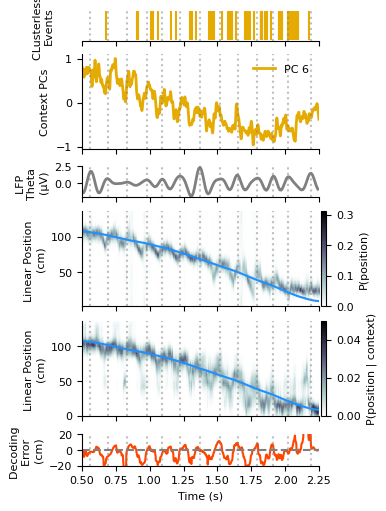

In [219]:
# analysis = analysis_all
interval = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
interval = interval[5]

from scipy.ndimage import gaussian_filter1d
st = interval[0]
en = interval[1]
pc_inds = [0, 1]
pc_inds = [5, 3, 0]
pc_inds = [5]
smooth_width = 3

# fig, ax_array = plt.subplots(
#     nrows=6,
#     ncols=1,
#     sharex="col",
#     height_ratios=[3,3, 1,1, 1,3],
#     # width_ratios=(10, 1),
#     # figsize=(7, 6),
#     figsize=(7, 9),
#     layout="constrained",
# )

fig, ax_array = plt.subplots(
    nrows=6,
    ncols=1,
    sharex="col",
    height_ratios=[1,3,1,3,3,1],
    # width_ratios=(10, 1),
    # figsize=(7, 6),
    figsize=(3.75, 5),
    layout="constrained",
)

z_ax = ax_array[0]
c_ax = ax_array[1]
lfp_ax = ax_array[2]
eric_ax = ax_array[3]
c3po_ax = ax_array[4]
err_ax = ax_array[5]



plt.rcParams["font.size"] = 8

ax = ax_array#[:, 0]

t_theta = theta_phase_df.index.values
ind_theta = np.logical_and(
    t_theta >= st,
    t_theta <= en,
)

t_lfp = t_theta[ind_theta] - st
lfp_plot = theta_phase_df.signal.values[ind_theta] / 100
lfp_ax.plot(
    t_theta[ind_theta] - st,
    lfp_plot,
    c="grey",
    lw=2,
    zorder=-10,
    label="LFP Theta Band",
)

ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, smooth_width, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    c_ax.plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=1 - j,
        label=f"PC {pc_inds[j]+1}",
        lw=2,
        color = plt.cm.Dark2(pc_inds[j] / 8)
    )
    # break


ind_eric = np.logical_and(
    eric_results.time >= st,
    eric_results.time <= en,
)
cm = eric_ax.imshow(
    eric_posterior[ind_eric].T,
    aspect="auto",
    origin="lower",
    cmap="bone_r",
    extent=[0, en - st, eric_results.position.min(), eric_results.position.max()],
    zorder=-3,
    rasterized=True
)
cb = fig.colorbar(cm, ax=eric_ax, orientation="vertical", fraction=0.05, pad=0.01,
                  label="P(position)")

pos_ind = np.logical_and(
    pos_df.index >= st,
    pos_df.index <= en,
)
t_pos = pos_df.index[pos_ind] - st
pos_plot = pos_df.linear_position[pos_ind]
for a in [eric_ax, c3po_ax]:
    a.plot(
        t_pos,
        pos_plot,
        c="dodgerblue",
        # s=5,
        zorder=-2,
        label="True Position",
        rasterized=True
    )

ind_pred = np.logical_and(t_pred >= st, t_pred <= en)
pos_pred = feature_pred[ind_pred]
# ax[0].plot(
#     t_pred[ind_pred] - st,
#     pos_pred,
#     c="mediumseagreen",
#     lw=1,
#     alpha=1,
#     label="Decoded Position",
#     zorder=-1,
# )
xx,yy = np.meshgrid(t_pred[ind_pred] - st, feature_pred_bins)
cm = c3po_ax.pcolormesh(
    xx,
    yy,
    feature_pred_posterior[ind_pred].T,
    cmap="bone_r",
    shading="auto",
    zorder=-20,
    vmin=0,
    vmax=0.05,
    rasterized=True
)
cb = fig.colorbar(cm, ax=c3po_ax, orientation="vertical", fraction=0.05, pad=0.01,
                  label="P(position | context)")
# ax[1].imshow(
#     feature_pred_posterior[ind_pred].T,
#     aspect="auto",
#     origin="lower",
#     cmap="bone_r",
#     extent=[0, t_pred[ind_pred][-1] - t_pred[ind_pred][0], feature_pred_bins[0], feature_pred_bins[-1]],
#     zorder=-20,
#     clim=[0, 0.05]
# )

pos_upsampled = np.interp(
    t_pred[ind_pred] - st,
    t_pos,
    pos_plot,
)
err_ax.plot(t_pred[ind_pred] - st, pos_pred[:, 0] - pos_upsampled, color="orangered")
err_ax.axhline(0, ls="--", c="grey")
err_ax.set_ylim(-20, 20)


# Spike Events
ind_z = np.logical_and(
    analysis.t >= st,
    analysis.t <= en,
)
z_plot = z_pca[ind_z][:, pc_inds]
z_t_plot = analysis.t[ind_z] - st


z_thresh_list = []
for i, pc_ind in enumerate(pc_inds):
    thresh = np.percentile(z_plot[:, i], 2.5)
    z_thresh_list.append(thresh)
    ind_keep = z_plot[:, i] < thresh

    color = plt.cm.Dark2(pc_inds[i] / 8)
    z_ax.vlines(z_t_plot[ind_keep], -i, -i-.9, color=color, lw=1.5, alpha=1)
    # ax[4].set_ylim(-1, 1)


ax[1].legend(frameon=False, loc = "upper right", )
# ax[0].legend(loc="upper right")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[-1].set_xlabel("Time (s)")
eric_ax.set_ylabel("Linear Position \n(cm)")
c3po_ax.set_ylabel("Linear Position \n(cm)")
c_ax.set_ylabel("Context PCs")
err_ax.set_ylabel("Decoding \nError \n(cm)")
lfp_ax.set_ylabel("LFP \nTheta \n(µV)")
# ax[4].set_ylabel(f"Spike /nEvents \n($Z_{pc_inds[0]+1}$ < -.3)", labelpad=20)
z_ax.set_ylabel(f"CLusterless \nEvents", labelpad=20)
z_ax.set_yticks([])
z_ax.spines['left'].set_visible(False)


d_lfp = np.diff(lfp_plot)
upward = (d_lfp > 0).astype(int)
peaks = np.where(np.diff(upward) == -1)[0] + 1
peaks = t_lfp[peaks]
for a in ax:
    for p in peaks:
        if p >= 0 and p <= (en - st):
            a.axvline(p, color="grey", ls=":", alpha=0.5)

plt.xlim(0.5, 2.25)

plt.rcParams["svg.fonttype"] = "none"

# ylim = ax[-1].get_ylim()
# # ax[-1].fill_between([1.2,1.4], ylim[0], ylim[1], facecolor="grey", alpha=0.2, zorder = -10)
# ax[-1].set_ylim(ylim)

fig.savefig(
    fig_dir / f"example_decode_and_precessions_traces_multi_pc_V2.svg",
)

Text(0, 0.5, 'Context \nPCs')

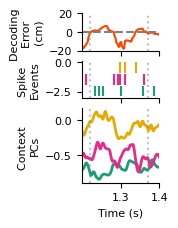

In [33]:
# Zoom for sequence compression in theta cycle

t_rng = st+.8, st+1
t_rng = st+1.2, st+1.4

fig, ax = plt.subplots(
    nrows=3,
    ncols=1,
    sharex="col",
    height_ratios=[1,1, 2],
    # height_ratios=[3,3, 1,1, 1,3],
    # width_ratios=(10, 1),
    # figsize=(7, 6),
    figsize=(1,2.2),
    # layout="constrained",
)
c_ax = ax[2]
z_ax = ax[1]
err_ax = ax[0]

# Context
ind_context = np.logical_and(
    analysis.t_interp >= t_rng[0],
    analysis.t_interp <= t_rng[1],
)
ind_context_full = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
c_plot_full = analysis.c_pca_interp[ind_context_full][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, smooth_width, axis=0, mode="nearest")
# c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot_full), axis=0))
for j in range(c_plot.shape[1]):
    plt.plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=1 - j,
        label=f"PC {pc_inds[j]+1}",
        lw=2,
        color = plt.cm.Dark2(pc_inds[j] / 8)
    )
    # break
# c_ax.set_ylim(-1, 1)

# Spike Events
ind_z = np.logical_and(
    analysis.t >= t_rng[0],
    analysis.t <= t_rng[1],
)
z_plot = z_pca[ind_z][:, pc_inds]
z_t_plot = analysis.t[ind_z] - st



for i, pc_ind in enumerate(pc_inds):
    thresh = z_thresh_list[i]
    z_thresh_list.append(thresh)
    ind_keep = z_plot[:, i] < thresh

    color = plt.cm.Dark2(pc_inds[i] / 8)
    z_ax.vlines(z_t_plot[ind_keep], -i, -i-.9, color=color, lw=1.5, alpha=1)
    # ax[4].set_ylim(-1, 1)


# Error
ind_err = np.logical_and(t_pred >= t_rng[0], t_pred <= t_rng[1])
pos_pred = feature_pred[ind_err]
pos_upsampled = np.interp(
    t_pred[ind_err] - st,
    t_pos,
    pos_plot,
)
err_ax.plot(t_pred[ind_err] - st, pos_pred[:, 0] - pos_upsampled, color="orangered")
err_ax.axhline(0, ls="--", c="grey")
err_ax.set_ylim(-20, 20)

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
c_ax.set_xlabel("Time (s)")


d_lfp = np.diff(lfp_plot)
upward = (d_lfp > 0).astype(int)
peaks = np.where(np.diff(upward) == -1)[0] + 1
peaks = t_lfp[peaks]
for a in ax:
    for p in peaks:
        if p >= 0 and p <= (en - st):
            a.axvline(p, color="grey", ls=":", alpha=0.5)

ax[0].set_xlim(t_rng[0]-st, t_rng[1]-st)

err_ax.set_ylabel("Decoding \nError \n(cm)")
z_ax.set_ylabel("Spike \nEvents")
c_ax.set_ylabel("Context \nPCs")
# fig.savefig(fig_dir / f"example_decode_and_precessions_traces_multi_pc_zoom.svg", dpi=300, bbox_inches="tight")

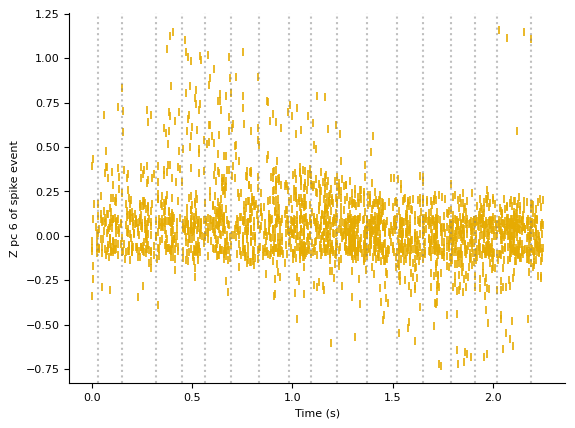

In [34]:

fig = plt.figure()
ax = fig.add_subplot(111)
ind_z = np.logical_and(
    analysis.t >= st,
    analysis.t <= en,
)

z_plot = z_pca[ind_z][:, pc_inds]
z_t_plot = analysis.t[ind_z] - st

ind_keep = z_plot[:, 0] < -.2
ind_keep = np.ones(z_plot.shape[0], dtype=bool)

# plt.scatter(z_t_plot[ind_keep], z_plot[ind_keep, 0],marker="|")
color = plt.cm.Dark2(pc_inds[0] / 8)
plt.scatter(z_t_plot[ind_keep], z_plot[ind_keep, 0],marker="|", color=color, lw=1.2)
for p in peaks:
    if p >= 0 and p <= (en - st):
        ax.axvline(p, color="grey", ls=":", alpha=0.5)

plt.ylabel(f"Z pc {pc_inds[0]+1} of spike event")
plt.xlabel("Time (s)")
ax.spines[["top", "right"]].set_visible(False)

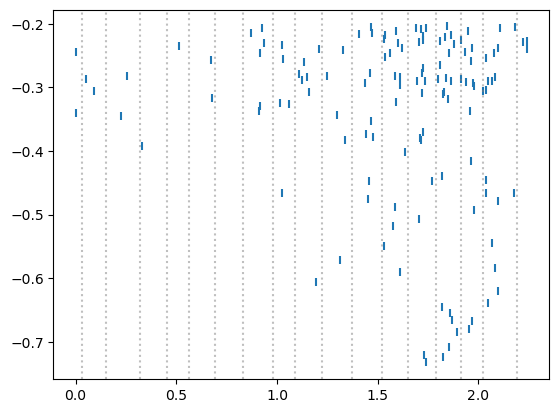

In [21]:

fig = plt.figure()
ax = fig.add_subplot(111)
ind_z = np.logical_and(
    analysis.t >= st,
    analysis.t <= en,
)

z_plot = z_pca[ind_z][:, pc_inds]
z_t_plot = analysis.t[ind_z] - st

ind_keep = z_plot[:, 0] < -.2
# ind_keep = np.ones(z_plot.shape[0], dtype=bool)

plt.scatter(z_t_plot[ind_keep], z_plot[ind_keep, 0],marker="|")
# plt.scatter(z_t_plot[ind_keep], np.zeros_like(z_t_plot[ind_keep]),marker="|",lw=1)
for p in peaks:
    if p >= 0 and p <= (en - st):
        ax.axvline(p, color="grey", ls=":", alpha=0.5)

# Decode error power spectrum

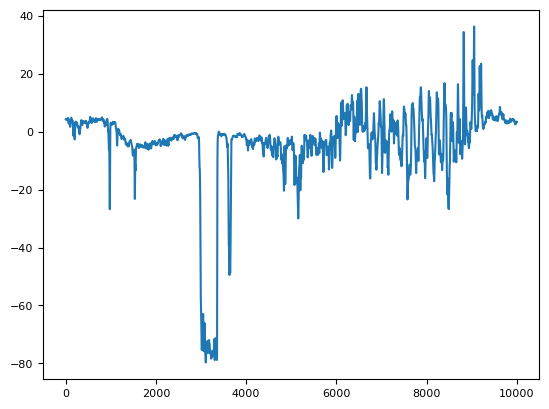

In [225]:
ind_pos = np.digitize(t_pred, pos_df.index.values)
true_pos = pos_df.linear_position.values[ind_pos]



dist_ = feature_pred[:,0] - true_pos
# dist_sign = np.sign(dist_)
# dist_ = graph_distance_between_points(environment, feature_pred[:,0], true_pos) * dist_sign

plt.plot(dist_[100000:110000])

t_pred_interp = np.arange(t_pred[0], t_pred[-1], .001)
dist_interp = np.interp(t_pred_interp, t_pred, dist_)

In [205]:
window_size = 1000
nfft = 100000


f, mid, lo, hi = analysis.power_spectrum(
    intervals=all_running_intervals,
    # intervals = center_intervals,

    window_size=window_size,
    nfft=nfft,
    pca=True,
    # sourced_data = (t_pred_interp,np.abs(dist_interp[:,None])),
    sourced_data = (t_pred_interp,dist_interp[:,None])

)



(1.0, 20.0)

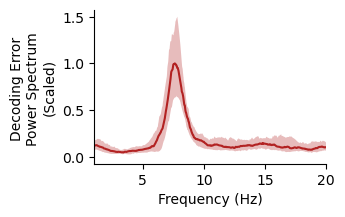

In [206]:
plot_f = f.copy()
plot_mid = mid * plot_f

fig = plt.figure(figsize=(3,2))
ax = plt.gca()
scale = np.max(plot_mid,axis=1, keepdims=True)
plot_mid = plot_mid / scale
plot_lo = lo * plot_f / scale
plot_hi = hi * plot_f / scale
ax.plot(plot_f, plot_mid.T, c='firebrick')
ind_plot = np.logical_and(plot_f >= 1, plot_f <= 20)
ax.fill_between(plot_f[ind_plot], plot_lo[0][ind_plot], plot_hi[0][ind_plot ], facecolor='firebrick', alpha=.3)

# plot_f = f_theta.copy()
# plot_mid = mid_theta * plot_f
# plot_mid = plot_mid / np.max(plot_mid)
# plot_mid = plot_mid / np.max(plot_mid,axis=1, keepdims=True)
# plt.plot(plot_f, plot_mid.T, c='k')


# plt.xscale('log')

ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Decoding Error \nPower Spectrum \n(Scaled)")
plt.xlim(1,20)
# fig.savefig(fig_dir / "decoding_error_power_spectrum.svg", dpi=300, bbox_inches="tight")

Text(0.5, 0, 'Theta Phase (rad)')

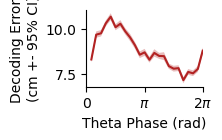

In [207]:
from c3po.analysis.analysis import bootstrap_confidence_interval

ind_theta = np.digitize(t_pred_interp, theta_phase_df.index.values)
results, bins = analysis.bin_context_by_feature(
    feature_times = theta_phase_df.index.values,
    feature = theta_phase_df.phase.values,
    alt_data = (t_pred_interp, np.abs(dist_interp[:,None])),
    valid_intervals = all_running_intervals,
    bins = 25
)

mid = [np.mean(r, axis=0) for r in results]
lo = []
hi = []
for r in results:
    lo_i, hi_i = bootstrap_confidence_interval(r, num_bootstrap_samples=1000, confidence_level=0.95)
    lo.append(lo_i)
    hi.append(hi_i)
lo = np.squeeze(lo)
hi = np.squeeze(hi)

# lo = np.squeeze([np.percentile(r, 25, axis=0) for r in results])
# hi = np.squeeze([np.percentile(r, 75, axis=0) for r in results])

bins_plot = np.mean(np.diff(bins)) + bins[:-1]

fig = plt.figure(figsize=(1.5,1))
ax = plt.gca()
plt.plot(bins_plot, mid, c='firebrick')
plt.fill_between(bins_plot, lo, hi, facecolor='firebrick', alpha=.3)
ax.set_xlim(0,2*np.pi)
ax.set_xticks([0, np.pi, 2*np.pi], labels=["0", "$\pi$", "$2\pi$"])
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel("Decoding Error \n(cm +- 95% CI)")
ax.set_xlabel("Theta Phase (rad)")

# fig.savefig(fig_dir / "decoding_error_theta_phase.svg", dpi=300, bbox_inches="tight")


# Context Sequence Compression

In [ ]:
pc_inds = [5, 3, 0,]
# pc_inds = [5,11, 0]
# pc_inds = [5,13, 0]
# pc_inds = [5,18,0]
pc_thresh = {
    5:-.3,
    3:-.3,
    0:-.3,
    1:-.3,
    6:-.3,
    13:.3
}
from c3po.analysis.intervals import interval_list_contains_ind, interval_list_contains
# pc_inds = np.arange(8)

In [146]:
z_pca = analysis.z @ analysis.pca.components_.T
z_pca_mag = np.linalg.norm(z_pca, axis = 1)

In [147]:
# pos_bins = np.linspace(10,120,20)
# ind_z = interval_list_contains_ind(left_running_intervals, analysis.t)
# pc = pc_inds[1]
# thresh = pc_thresh[pc]
# z_plot = z_pca[ind_z][:, pc]
# z_t_plot = analysis.t[ind_z]

# # ind_valid = z_plot < -.4
# ind_valid = z_plot < 100

# # ind_valid = np.logical_and(z_plot<0, z_plot>-.5)

# z_mag_ratio = z_plot / z_pca_mag[ind_z]
# ind_valid = z_mag_ratio <-.1
# # ind_valid = np.logical_and(z_plot<-.2, )

# z_plot = z_plot[ind_valid]
# z_t_plot = z_t_plot[ind_valid]

# pos_ind = np.digitize(z_t_plot, pos_df.index.values)
# pos_z = pos_df.linear_position.values[pos_ind]

# H, _ = np.histogram(pos_z, bins=pos_bins)
# # H = H/occupancy

# plt.plot(pos_bins[1:], H)

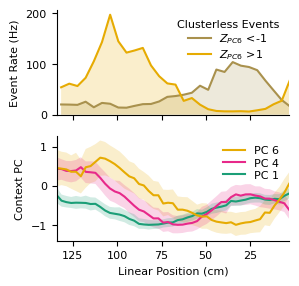

In [ ]:
pos_bins = np.linspace(.2,134,30)

pos_left_ind = interval_list_contains_ind(left_running_intervals, pos_df.index.values)
pos_left = pos_df.linear_position.values[pos_left_ind]
occupancy, _ = np.histogram(pos_left, bins=pos_bins)
dt_pos = np.median(np.diff(pos_df.index.values))
occupancy = occupancy * dt_pos # in seconds

# all_left_t = interval_list_contains(left_running_intervals, analysis.t)
# all_left_pos_ind = np.digitize(all_left_t, pos_df.index.values)
# all_left_pos = pos_df.linear_position.values[all_left_pos_ind]
# occupancy, _ = np.histogram(all_left_pos, bins=pos_bins)


ind_z = interval_list_contains_ind(left_running_intervals, analysis.t, )

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (3,3),
                       sharex=True)

spike_pcs = [5]
for i,pc in enumerate(spike_pcs):
    for sign in [-1,1]:

        z_plot = z_pca[ind_z][:, pc]
        z_t_plot = analysis.t[ind_z]

        # ind_valid = z_plot < np.percentile(z_plot, 10)
        thresh = .3 * sign
        if thresh <0:
            ind_valid = z_plot < thresh
        else:
            ind_valid = z_plot >thresh
        z_plot = z_plot[ind_valid]
        z_t_plot = z_t_plot[ind_valid]

        pos_ind = np.digitize(z_t_plot, pos_df.index.values)
        pos_z = pos_df.linear_position.values[pos_ind]
        pos_z = pos_df.linear_position.values[np.digitize(z_t_plot, pos_df.index.values)]

        H, _ = np.histogram(pos_z, bins=pos_bins)
        H = H/occupancy
        # H = H/H.mean()

        bx = np.diff(pos_bins) / 2 + pos_bins[:-1]
        color = plt.cm.Dark2(pc/8)
        if pc == 6:
            color="mediumorchid"
        if sign < 0:
            from matplotlib.colors import to_rgb
            rgb = np.array(to_rgb(color))
            gray = .5
            amount = .6
            color = tuple((1 - amount) * rgb + amount * gray)

        # label = f"Z PC {pc+1} {'>' if sign > 0 else '<'}{sign}"
        label = f"$Z_{{PC {pc+1}}}$ {'>' if sign > 0 else '<'}{sign}"
        ax[0].plot(bx, H, color=color, label = label)
        ax[0].fill_between(bx, 0, H, facecolor=color, alpha=0.2)

        # ax[i].scatter(pos_z, z_plot, color=color, s=10, alpha = .1, marker = '|')
        ax[0].spines[['top', 'right']].set_visible(False)
        # ax[i].set_ylim(-1,0)
        # ax[i].set_xlim(130,0)

#########################################################
######### CONTEXT #######################################
#########################################################

results, bins_pos = analysis.bin_context_by_feature(
    feature_times = pos_df.index.values,
    feature = pos_df.linear_position.values,
    pca = True,
    valid_intervals = left_running_intervals,
    bins = 50
)

mid = np.array([np.median(r, axis=0) for r in results])
lo = np.array([np.percentile(r, 25, axis=0) for r in results])
hi = np.array([np.percentile(r, 75, axis=0) for r in results])
bx = np.mean(np.diff(bins_pos)) + bins_pos[:-1]



for i,pc in enumerate(pc_inds):
# for pc in np.arange(10):
    color = plt.cm.Dark2(pc / 8)
    if pc == 6:
        color = "mediumorchid"
    val = mid[:, pc]
    scale = np.max(np.abs(val))
    # scale = -np.min(val)
    # val =val - np.mean(val)
    val = val / scale
    # val = val / np.abs(np.min(val))
    # val =np.concatenate([val, val])
    # bx = np.concatenate([bins_pos, bins_pos + 2*np.pi])

    plt.plot(bx, val, c=color, label=f"PC {pc+1}", zorder = -i)
    plt.fill_between(bx, lo[:, pc]/scale, hi[:, pc]/scale, facecolor=color, alpha=0.2, zorder = -10)

for a in ax:
    a.spines[['top', 'right']].set_visible(False)
plt.xlim(bx[-1], bx[0])
ax[0].set_ylim(0, ax[0].get_ylim()[1])

ax[0].set_ylabel("Event Rate (Hz)")
ax[0].legend(frameon=False, title="Clusterless Events", labelspacing=0.2)

ax[1].set_ylabel("Context PC")
ax[1].set_xlabel("Linear Position (cm)")
ax[1].legend(frameon=False,  labelspacing=0.2)

plt.rcParams['svg.fonttype'] = 'none'
fig.savefig(fig_dir/ "position_context_and_rate.svg")

In [203]:
# pos_bins = np.linspace(.2,134,30)

# pos_left_ind = interval_list_contains_ind(left_running_intervals, pos_df.index.values)
# pos_left = pos_df.linear_position.values[pos_left_ind]
# occupancy, _ = np.histogram(pos_left, bins=pos_bins)

# all_left_t = interval_list_contains(left_running_intervals, analysis.t)
# all_left_pos_ind = np.digitize(all_left_t, pos_df.index.values)
# all_left_pos = pos_df.linear_position.values[all_left_pos_ind]
# occupancy, _ = np.histogram(all_left_pos, bins=pos_bins)


# ind_z = interval_list_contains_ind(left_running_intervals, analysis.t, )

# fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (3,3),
#                        sharex=True)
# for i,pc in enumerate(pc_inds):
#     z_plot = z_pca[ind_z][:, pc]
#     z_t_plot = analysis.t[ind_z]

#     # ind_valid = z_plot < np.percentile(z_plot, 10)
#     thresh = pc_thresh.get(pc, -0.3)
#     if thresh <0:
#         ind_valid = z_plot < thresh
#     else:
#         ind_valid = z_plot >thresh
#     z_plot = z_plot[ind_valid]
#     z_t_plot = z_t_plot[ind_valid]

#     pos_ind = np.digitize(z_t_plot, pos_df.index.values)
#     pos_z = pos_df.linear_position.values[pos_ind]
#     pos_z = pos_df.linear_position.values[np.digitize(z_t_plot, pos_df.index.values)]

#     H, _ = np.histogram(pos_z, bins=pos_bins)
#     H = H/occupancy
#     H = H/H.mean()

#     bx = np.diff(pos_bins) / 2 + pos_bins[:-1]
#     color = plt.cm.Dark2(pc/8)
#     if pc == 6:
#         color="mediumorchid"
#     ax[0].plot(bx, H, color=color)

#     # ax[i].scatter(pos_z, z_plot, color=color, s=10, alpha = .1, marker = '|')
#     ax[0].spines[['top', 'right']].set_visible(False)
#     # ax[i].set_ylim(-1,0)
#     # ax[i].set_xlim(130,0)

# #########################################################
# ######### CONTEXT #######################################
# #########################################################

# results, bins_pos = analysis.bin_context_by_feature(
#     feature_times = pos_df.index.values,
#     feature = pos_df.linear_position.values,
#     pca = True,
#     valid_intervals = left_running_intervals,
#     bins = 50
# )

# mid = np.array([np.median(r, axis=0) for r in results])
# lo = np.array([np.percentile(r, 25, axis=0) for r in results])
# hi = np.array([np.percentile(r, 75, axis=0) for r in results])
# bx = np.mean(np.diff(bins_pos)) + bins_pos[:-1]


# for pc in pc_inds:
# # for pc in np.arange(10):
#     color = plt.cm.Dark2(pc / 8)
#     if pc == 6:
#         color = "mediumorchid"
#     val = mid[:, pc]
#     scale = np.max(np.abs(val))
#     # scale = -np.min(val)
#     # val =val - np.mean(val)
#     val = val / scale
#     # val = val / np.abs(np.min(val))
#     # val =np.concatenate([val, val])
#     # bx = np.concatenate([bins_pos, bins_pos + 2*np.pi])

#     plt.plot(bx, val, c=color, label=f"PC {pc+1}")
#     plt.fill_between(bx, lo[:, pc]/scale, hi[:, pc]/scale, facecolor=color, alpha=0.2, zorder = -1)

# for a in ax:
#     a.spines[['top', 'right']].set_visible(False)
# plt.xlim(bx[-1], bx[0])

Text(0, 0.5, 'Context PC \n(Scaled)')

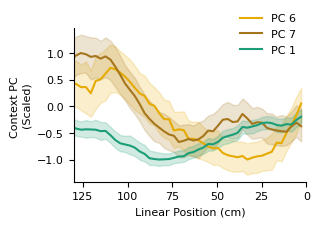

In [116]:
results, bins_pos = analysis.bin_context_by_feature(
    feature_times = pos_df.index.values,
    feature = pos_df.linear_position.values,
    pca = True,
    valid_intervals = left_running_intervals,
    bins = 50
)

mid = np.array([np.median(r, axis=0) for r in results])
lo = np.array([np.percentile(r, 25, axis=0) for r in results])
hi = np.array([np.percentile(r, 75, axis=0) for r in results])
bx = np.mean(np.diff(bins_pos)) + bins_pos[:-1]

fig = plt.figure(figsize=(3,2))
ax = plt.gca()
# fig, ax_list = plt.subplots(nrows=2, sharex=True, figsize=(3,2))
for pc in pc_inds:
# for pc in np.arange(10):
    color = plt.cm.Dark2(pc / 8)
    val = mid[:, pc]
    scale = np.max(np.abs(val))
    # val =val - np.mean(val)
    val = val / scale
    # val = val / np.abs(np.min(val))
    # val =np.concatenate([val, val])
    # bx = np.concatenate([bins_pos, bins_pos + 2*np.pi])

    plt.plot(bx, val, c=color, label=f"PC {pc+1}")
    plt.fill_between(bx, lo[:, pc]/scale, hi[:, pc]/scale, color=color, alpha=0.2, zorder = -1)

fig.legend(bbox_to_anchor=(.9, 1), frameon=False)
ylim = plt.ylim()
# plt.fill_between(pos_rng, ylim[0], ylim[1], color="grey", alpha=0.2)
plt.ylim(ylim)
plt.xlim(130,0)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Linear Position (cm)")
ax.set_ylabel("Context PC \n(Scaled)")

NameError: name 'pos_rng' is not defined

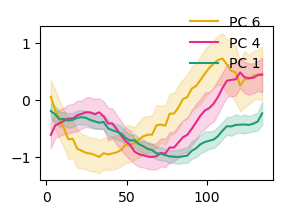

In [12]:
results, bins_pos = analysis.bin_context_by_feature(
    feature_times = pos_df.index.values,
    feature = pos_df.linear_position.values,
    pca = True,
    valid_intervals = left_running_intervals,
    bins = 50
)

mid = np.array([np.median(r, axis=0) for r in results])
lo = np.array([np.percentile(r, 25, axis=0) for r in results])
hi = np.array([np.percentile(r, 75, axis=0) for r in results])
bx = np.mean(np.diff(bins_pos)) + bins_pos[:-1]

fig = plt.figure(figsize=(3,2))
ax = plt.gca()
for pc in pc_inds:
# for pc in np.arange(10):
    color = plt.cm.Dark2(pc / 8)
    val = mid[:, pc]
    scale = np.max(np.abs(val))
    # val =val - np.mean(val)
    val = val / scale
    # val = val / np.abs(np.min(val))
    # val =np.concatenate([val, val])
    # bx = np.concatenate([bins_pos, bins_pos + 2*np.pi])

    plt.plot(bx, val, c=color, label=f"PC {pc+1}")
    plt.fill_between(bx, lo[:, pc]/scale, hi[:, pc]/scale, color=color, alpha=0.2, zorder = -1)

fig.legend(bbox_to_anchor=(.9, 1), frameon=False)
ylim = plt.ylim()
plt.fill_between(pos_rng, ylim[0], ylim[1], color="grey", alpha=0.2)
plt.ylim(ylim)
plt.xlim(130,0)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Linear Position (cm)")
ax.set_ylabel("Context PC \n(Scaled)")

In [205]:
pos_rng = (70,90)
pos_rng = (65,85)
pos_rng = (80,100)

from c3po.analysis.analysis import interval_list_contains_ind
# ind_left = interval_list_contains_ind(left_running_intervals, pos_df.index.values)
# ind_left.shape
valid_intervals = []
for left_interval in left_running_intervals:
    ind_left = np.logical_and(pos_df.index.values >= left_interval[0], pos_df.index.values <= left_interval[1])
    pos_left = pos_df.linear_position.values[ind_left]
    ind_rng = np.where(np.logical_and(pos_left >= pos_rng[0], pos_left <= pos_rng[1]))[0]
    if ind_rng.size > 0:
        valid_intervals.append((pos_df.index.values[ind_left][ind_rng[0]], pos_df.index.values[ind_left][ind_rng[-1]]))
valid_intervals = np.array(valid_intervals)
bins = 21
results_theta, bins_theta = analysis.bin_context_by_feature(
    feature_times = theta_phase_df.index.values,
    feature = theta_phase_df.phase.values,
    pca=True,
    valid_intervals = valid_intervals,
    bins = bins,
    interpolated = True,
)
mid_theta = np.array([np.mean(r, axis=0) for r in results_theta])
lo_theta = np.array([np.percentile(r, 25, axis=0) for r in results_theta])
hi_theta = np.array([np.percentile(r, 75, axis=0) for r in results_theta])
bins_theta_plot = np.mean(np.diff(bins_theta)) + bins_theta[:-1]
np.sum(valid_intervals[:,1] - valid_intervals[:,0])

np.float64(19.51996946334839)

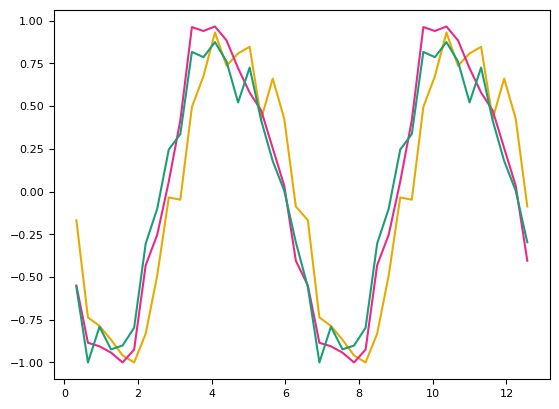

In [206]:
for pc in pc_inds:
    color = plt.cm.Dark2(pc / 8)
    val = mid_theta[:, pc]
    val =val - np.mean(val)
    # val = val / np.max(np.abs(val))
    val = val / np.abs(np.min(val))
    val =np.concatenate([val, val])
    bx = np.concatenate([bins_theta_plot, bins_theta_plot + 2*np.pi])
    plt.plot(bx, val, c=color)

In [207]:
smooth_width = None

lags, cross_corrs = analysis.cross_correlation(pca=True, intervals=valid_intervals, max_lag_seconds = .2,
                           processes = 16, dim_limit = 8, smooth_context = smooth_width)

lags_full, cross_corrs_full = analysis.cross_correlation(pca=True, intervals=left_running_intervals, max_lag_seconds = .7,
                           processes = 16, dim_limit = 8, smooth_context = smooth_width)

Sampling frequency: 1000.07 Hz


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 64/64 [00:00<00:00, 214.50it/s]


Sampling frequency: 1000.07 Hz


100%|██████████| 64/64 [00:00<00:00, 70.93it/s]


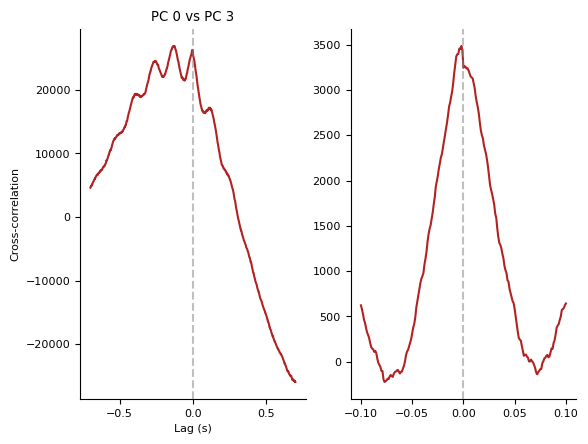

In [208]:
pc_pair = (0, 5)
pc_pair = (3, 5)
pc_pair = (0, 3)
fig, ax = plt.subplots(ncols=2)

ax[0].plot(lags_full, cross_corrs_full[pc_pair[0], pc_pair[1]], c='firebrick')

ax[0].set_xlabel('Lag (s)')
ax[0].set_ylabel('Cross-correlation')
ax[0].set_title(f'PC {pc_pair[0]} vs PC {pc_pair[1]}')

ind = np.where(np.abs(lags) < .1)[0]
ax[1].plot(lags[ind], cross_corrs[pc_pair[0], pc_pair[1]][ind], c='firebrick')

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    a.axvline(0, ls='--', c='grey', alpha=.5)

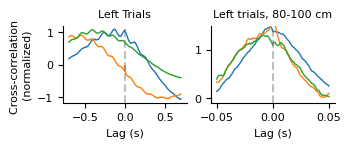

In [211]:
pc_pair_list = [(0, 3), (0, 5), (3, 5)]
# pc_pair_list = [(3, 0), (5, 0), (5, 3)]
fs = plt.rcParams['font.size']
plt.rcParams['font.size'] = 8
fig, ax = plt.subplots(ncols = 2, figsize = (3.5,1))

fast_lim = (-.005,.15)
fast_lim = (-.05,.05)
for pc_pair in pc_pair_list:
    val = cross_corrs[pc_pair[0], pc_pair[1]]
    # val = val / np.max(np.abs(val))
    scale =  np.percentile(np.abs(val), 90)
    val = val / scale
    ind = np.where(np.logical_and(lags >= fast_lim[0], lags <= fast_lim[1]))[0]
    c0 = plt.cm.Dark2(pc_pair[0] / 8)
    c1 = plt.cm.Dark2(pc_pair[1] / 8)
    c0 = None
    lw = 1
    plt.plot(lags[ind], val[ind], label=f"PC {pc_pair[0]+1} vs PC {pc_pair[1]+1}", color=c0, lw=lw)
    # plt.plot(lags[ind], val[ind], label=f"PC {pc_pair[0]} vs PC {pc_pair[1]}",color=c1, ls=':', lw=lw)

    val = cross_corrs_full[pc_pair[0], pc_pair[1]]
    scale =  np.percentile(np.abs(val), 90)
    val = val /scale#/ np.max(np.abs(val))
    ax[0].plot(lags_full, val,c= c0, lw=lw)
    # ax[0].plot(lags_full, val,c= c1, ls=':', lw=lw)


# fig.legend(bbox_to_anchor=(.9, .9), loc="upper left", frameon=False)
ax[0].set_xlabel('Lag (s)')
ax[0].set_ylabel('Cross-correlation \n(normalized)')
ax[0].set_title('Left Trials', fontsize=8)
ax[1].set_xlabel('Lag (s)')
ax[1].set_title(f"Left trials, {pos_rng[0]}-{pos_rng[1]} cm", fontsize=8)
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    a.axvline(0, ls='--', c='grey', alpha=.5)
ax[0].set_yticks([-1,0,1])
ax[1].set_ylim(-.1,1.5)


# fig.savefig(fig_dir / f"cross_correlation_precession.svg", dpi=300, bbox_inches="tight")

plt.rcParams['font.size'] = fs

# Precession Plot (One PC)

In [220]:
n_pos = 100
n_theta = 50

n_pos = 50
n_theta = 20

# n_pos = 150
# n_theta = 75
heatmap_pos_rng = (10, 120)
context_1d , b1 = analysis.bin_context_by_feature(
    pos_df.linear_position.values,
    pos_df.index,
    pca=True,
    bins=np.linspace(heatmap_pos_rng[0], heatmap_pos_rng[1], n_pos),

)

left_binned_context, b1, b2, counts_left = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    theta_phase_df.phase.values,
    theta_phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=left_running_intervals,
    bins_1=np.linspace(heatmap_pos_rng[0], heatmap_pos_rng[1], n_pos),
    bins_2=np.linspace(-.001, 2 * np.pi + 0.001, n_theta),
    return_counts=True,
)


right_binned_context, b1, b2, counts_right = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    theta_phase_df.phase.values,
    theta_phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=right_running_intervals,
    bins_1=np.linspace(heatmap_pos_rng[0], heatmap_pos_rng[1], n_pos),
    bins_2=np.linspace(0, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)

mid_left = np.array(
    [
        [
            np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
            for b in row
        ]
        for row in left_binned_context
    ]
)
mid_right = np.array(
    [
        [
            np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
            for b in row
        ]
        for row in right_binned_context
    ]
)

In [221]:
context_1d , b1 = analysis.bin_context_by_feature(
    pos_df.linear_position.values,
    pos_df.index,
    pca=True,
    bins=np.linspace(heatmap_pos_rng[0], heatmap_pos_rng[1], n_pos),
    valid_intervals = left_running_intervals
)

mid_1d = np.array(
    [
        np.nanmedian(b, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
        for b in context_1d
    ]
)
lo_1d = np.array(
    [
        np.percentile(b, 25, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
        for b in context_1d
    ]
)
hi_1d = np.array(
    [
        np.percentile(b, 75, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
        for b in context_1d
    ]
)
# lo_1d = np.array(
#     [
#         bootstrap_confidence_interval(b, num_bootstrap_samples=1000, confidence_level=0.95)[0]
#         if len(b) else np.nan * np.zeros(analysis.context_dim)
#         for b in context_1d
#     ]
# )
# hi_1d = np.array(
#     [
#         bootstrap_confidence_interval(b, num_bootstrap_samples=1000, confidence_level=0.95)[1]
#         if len(b) else np.nan * np.zeros(analysis.context_dim)
#         for b in context_1d
#     ]
# )

In [228]:
from c3po.analysis.analysis import bootstrap_confidence_interval
ind_theta = np.digitize(t_pred_interp, theta_phase_df.index.values)
err_results, err_bins = analysis.bin_context_by_feature(
    feature_times = theta_phase_df.index.values,
    feature = theta_phase_df.phase.values,
    alt_data = (t_pred_interp, np.abs(dist_interp[:,None])),
    valid_intervals = all_running_intervals,
    bins = 25
)

err_mid = [np.mean(r, axis=0) for r in err_results]
err_lo = []
err_hi = []

for r in err_results:
    lo_i, hi_i = bootstrap_confidence_interval(r, num_bootstrap_samples=1000, confidence_level=0.95)
    err_lo.append(lo_i)
    err_hi.append(hi_i)
err_lo = np.squeeze(err_lo)
err_hi = np.squeeze(err_hi)

/tmp/ipykernel_1248585/3052166246.py:30: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pos_z, theta_z, facecolor=color, cmap="RdBu_r", s=10, alpha=0.3, lw=0)


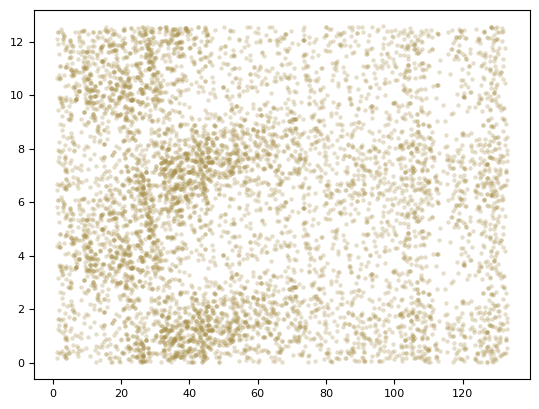

In [237]:
from c3po.analysis.intervals import interval_list_contains_ind
ind_z = interval_list_contains_ind(left_running_intervals, analysis.t)
pc = pc_inds[0]
# pc =
z_plot = z_pca[ind_z][:, pc]
z_t_plot = analysis.t[ind_z]

ind_valid = z_plot < -.3
# ind_valid = z_plot > .3
z_plot = z_plot[ind_valid]
z_t_plot = z_t_plot[ind_valid]

pos_ind = np.digitize(z_t_plot, pos_df.index.values)
pos_z = pos_df.linear_position.values[pos_ind]

theta_ind = np.digitize(z_t_plot, theta_phase_df.index.values)
theta_z = theta_phase_df.phase.values[theta_ind]

pos_z = np.concatenate([pos_z, pos_z])
theta_z = np.concatenate([theta_z, theta_z + 2 * np.pi])

color = plt.cm.Dark2(pc / 8)
from matplotlib.colors import to_rgb
rgb = np.array(to_rgb(color))
gray = .5
amount = .6
color = tuple((1 - amount) * rgb + amount * gray)
# color = 'grey'

plt.scatter(pos_z, theta_z, facecolor=color, cmap="RdBu_r", s=10, alpha=0.3, lw=0)

/tmp/ipykernel_1248585/3983201239.py:98: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0)


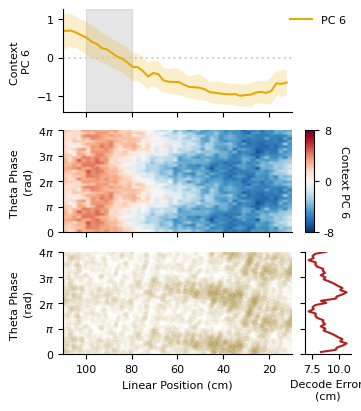

In [235]:
pc = 5
fs = plt.rcParams['font.size']
plt.rcParams['font.size'] = 8
plt.rcParams['svg.fonttype'] = 'none'

# fig, ax = plt.subplots(nrows=3, ncols=2,
#                        width_ratios=(5, 1), height_ratios=(1,3, 3, ),
#                        figsize=(3.5, 3), layout="constrained",
#                        )
fig, ax = plt.subplots(nrows=3, ncols=2,
                       width_ratios=(5, 1), height_ratios=(3,3, 3, ),
                       figsize=(3.5, 4), layout="constrained",
                       )

c_ax = ax[0,0]
heat_ax = ax[1,0]
z_ax = ax[2,0]
err_ax = ax[2,1]
# cb_ax = ax[1,1]
cb_container = ax[1, 1]
cb_container.axis("off")
# Skinny axis inside the existing subplot cell
cb_ax = cb_container.inset_axes([
    0,   # x position within cell
    0.0,    # y position
    0.20,   # width: make this smaller for skinnier colorbar
    1.0,    # height
])

ax[0,1].axis("off")
# ax[1,1].axis("off")


# plot context
x_plot = np.mean(np.diff(b1)) + b1[:-1]
for i,pc in enumerate(pc_inds):
    scale = np.max(np.abs(mid_1d[:, pc]))
    color = plt.cm.Dark2(pc / 8)
    c_ax.plot(x_plot, mid_1d[:, pc]/scale, c=color, zorder = -i, label=f"PC {pc+1}")
    c_ax.fill_between(x_plot, lo_1d[:, pc]/scale, hi_1d[:, pc]/scale, facecolor=color, alpha=.2, zorder = -(len(pc_inds)-i))
c_ax.set_xlim(10, 110)
c_ax.spines[["top", "right"]].set_visible(False)
c_ax.axhline(0, ls=":", c="lightgrey",zorder=-3)
c_ax.set_ylabel(f"Context \nPC {pc+1}")

# heatmap
pc = pc_inds[0]
data = mid_left[:,:-1,pc]
data = np.concatenate([data, data], axis=1)
cm = heat_ax.imshow(data.T, aspect="auto", origin="lower", extent=[10, 110, 0, 4*np.pi], cmap="RdBu_r",
           clim = (-8,8)
           )
cb = fig.colorbar(cm, cax=cb_ax, orientation="vertical", fraction=0.05, pad=0.01, label=f"Context PC {pc+1}", )
cb.set_label(f"Context PC {pc+1}", rotation=270, labelpad=10)
cb.set_ticks([-8, 0, 8])
cb.set_ticklabels([-8, 0, 8])
pos = cb_ax.get_position()

# z vals
color="grey"
color = plt.cm.Dark2(pc / 8)
from matplotlib.colors import to_rgb
rgb = np.array(to_rgb(color))
gray = .5
amount = .5
color = tuple((1 - amount) * rgb + amount * gray)
z_ax.scatter(pos_z, theta_z, facecolor=color, s=15, alpha=0.05, lw=0, edgecolor='none')
err_bins_plot = np.mean(np.diff(err_bins)) + err_bins[:-1]

y_err = np.concatenate([err_mid, err_mid])
x_err = np.concatenate([err_bins_plot, err_bins_plot + 2 * np.pi])
lo_err_plot = np.concatenate([err_lo, err_lo])
hi_err_plot = np.concatenate([err_hi, err_hi])
err_ax.plot(y_err, x_err, c='firebrick')
err_ax.fill_betweenx(x_err, lo_err_plot, hi_err_plot, facecolor='firebrick', alpha=.3)
err_ax.set_ylim(0, 4*np.pi)
err_ax.set_yticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi], labels=[""] *5)
err_ax.set_xlabel("Decode Error \n(cm)")
# err_ax.xaxis.tick_top()
# err_ax.xaxis.set_label_position('top')
err_ax.spines[["top", "right"]].set_visible(False)


xticks = [20,40,60,80,100]
for a in [heat_ax, z_ax]:
    a.set_xlim(10, 110)
    a.set_ylim(0, 4*np.pi)
    a.set_yticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi], labels=["0", "$\pi$", "$2\pi$", "$3\pi$", "$4\pi$"])
    a.set_ylabel("Theta Phase \n(rad)")
    a.spines[["top", "right"]].set_visible(False)
    a.set_xticks(xticks)

heat_ax.set_xticklabels([""] * len(xticks))
c_ax.set_xticks(xticks)
c_ax.set_xticklabels([""] * len(xticks))

z_ax.set_xlabel("Linear Position (cm)")
plt.subplots_adjust(hspace=0)

# fig.savefig(fig_dir / f"precession_heatmap_plus_scatter_pc{pc+1}.svg", dpi=300, bbox_inches="tight")

for a in ax[:,0]:
    a.set_xlim(110,10)

fig.legend(bbox_to_anchor=(1, 1), frameon=False)
ylim = c_ax.get_ylim()
c_ax.fill_between(pos_rng, ylim[0], ylim[1], color="grey", alpha=0.2, zorder = -10)
c_ax.set_ylim(ylim)


fig.savefig(fig_dir / f"precession_heatmap_plus_scatter_pc{pc+1}.svg", dpi=300, bbox_inches="tight")

plt.rcParams['font.size'] = fs


In [ ]:
plot_x =

In [ ]:
lo_err_plot

array([ 8.1339369 ,  9.49751724,  9.58503384, 10.15574331, 10.50350702,
        9.93193777, 10.10350724,  9.67932477,  9.32814424,  8.88678025,
        8.36932545,  8.50806988,  8.10875765,  8.45659538,  8.31363645,
        8.28070047,  7.77553075,  7.60971005,  7.63807981,  6.97956629,
        7.44173856,  7.36070962,  7.59699293,  8.60959148,  8.1339369 ,
        9.49751724,  9.58503384, 10.15574331, 10.50350702,  9.93193777,
       10.10350724,  9.67932477,  9.32814424,  8.88678025,  8.36932545,
        8.50806988,  8.10875765,  8.45659538,  8.31363645,  8.28070047,
        7.77553075,  7.60971005,  7.63807981,  6.97956629,  7.44173856,
        7.36070962,  7.59699293,  8.60959148])

/tmp/ipykernel_1523404/3704808711.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pos_z, theta_z, facecolor=color, cmap="RdBu_r", s=10, alpha=0.3, lw=0)


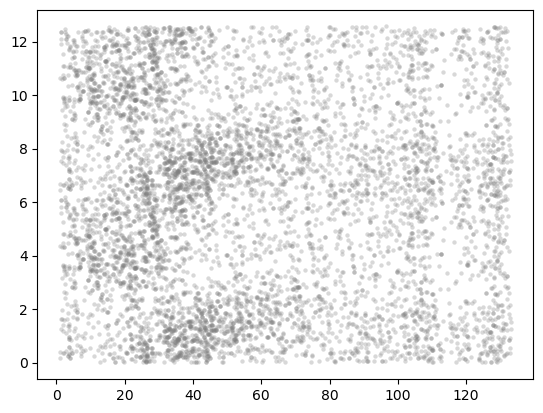

Text(0.5, 0, 'Mean Value')

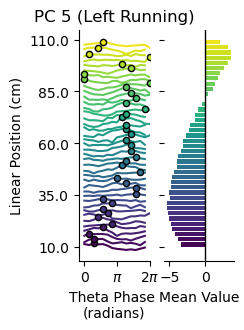

In [29]:
pc = 5
data = mid_left

# fig = plt.figure(figsize=(2, 5))

# fig, ax = plt.subplots(figsize=(3, 5), ncols=2, width_ratios=[2, 1], sharey=True)
fig, ax = plt.subplots(figsize=(2, 3), ncols=2, width_ratios=[1, 1], sharey=True)

val = data[:, :, pc].T

scale_factor = 0
for i in range(val.shape[-1]):
    val_i = val[:, i].copy()
    mid_i = np.nanmean(val_i)
    val_i = val_i - np.nanmean(val_i)
    scale_i = np.nanpercentile(np.abs(val_i), 97)
    if scale_i > scale_factor:
        scale_factor = scale_i


for i in range(val.shape[-1]):
    val_i = val[:, i].copy()
    mid_i = np.nanmean(val_i)

    val_i = val_i - np.nanmean(val_i)
    val_i = val_i / scale_factor
    # val_i = val_i / np.nanpercentile(np.abs(val_i), 97)
    # val_i = val_i / np.nanpercentile(np.abs(val), 97) *3
    c = plt.cm.viridis(i / val.shape[-1])
    ax[0].plot(b2[:], val_i + i * 1, c=c)
    ind_max = np.nanargmax(val[:, i])
    ind_min = np.nanargmin(val[:, i])
    ind_mark = ind_max
    ax[0].scatter(b2[ind_mark], val_i[ind_mark] + i * 1,
                  facecolor=c,edgecolor="k", s=20, zorder=50)

    ax[1].barh(i + 0.5, mid_i, color=plt.cm.viridis(i / val.shape[-1]))
    # ind_min = np.nanargmin(val[:, i])
    # plt.scatter(b2[ind_min], val_i[ind_min] + i * 1, c='r', s=100, zorder=50)

ax[0].set_xticks(
    np.linspace(0, 2 * np.pi, 3),
    ["0", r"$\pi$", r"$2\pi$"],
)
ax[0].set_yticks(
    np.linspace(0, val.shape[-1] * 1, 5),
    np.linspace(b1[0], b1[-1], 5),
)
ax[0].set_xlabel("Theta Phase \n(radians)")
ax[0].set_ylabel("Linear Position (cm)")
ax[0].set_title(f"PC {pc} (Left Running)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_xlim(-0.5, 2 * np.pi)


ax[1].spines["left"].set_visible(False)
ax[1].axvline(0, c="k", ls="-", lw=1)
# ax[1].set_xticks(
#     [-2, 0, 2],
# )
ax[1].set_xlabel("Mean Value")

# fig.savefig(
#     fig_dir / f"contextPCA_thetaPhase_position_PC{pc}_leftRunning.svg",
# )

# Ripple Decoding

In [86]:
t_feature = pos_df.index.values
feature = pos_df.linear_position.values[:, None]


# def cosine_similarity_weight(distances):
#     """
#     Converts cosine distances back into cosine similarities to act as weights.
#     scikit-learn's cosine metric returns 'cosine distance' (1 - similarity).
#     """
#     # Cosine similarity = 1 - cosine distance
#     return 1.0 - distances


# analysis.initialize_decoder(
#     "posterior_knn",
#     n_neighbors=300,
#     metric="cosine",
#     # weights="distance",
#     weights = cosine_similarity_weight,

#     # balance_groups=True,
#     # balance_groups=True,
#     multidim=False,
#     predict_method="weighted",
#     environment=environment,
#     feature_smooth_std = 4,
#     # predict_method="peak",
#     # solver = "newton-cholesky",
#     # n_jobs=4,
# )

analysis.initialize_decoder(
    "discretized_regression",
    # n_bins=70,
    max_iter=50,
    balance_groups=True,
    # balance_groups = False,
    multidim=False,
    predict_method="weighted",
    # n_jobs=4,
    environment=environment,
    feature_smooth_std = 4,
    normalize_decode_context = False,

    # fit_intervals=all_running_intervals
)


# analysis.initialize_decoder(
#     "discretized_regression",
#     # n_bins=70,
#     max_iter=500,
#     # balance_groups=True,
#     balance_groups = False,
#     multidim=False,
#     predict_method="weighted",
#     # n_jobs=4,
#     environment=environment,
#     feature_smooth_std = 4,
#     normalize_decode_context = False,
#     # fit_intervals=all_running_intervals
# )


# analysis.initialize_decoder(
#     "eric_decoder",
#     # n_neighbors=50,
#     # weights="distance",

#     # # balance_groups=True,
#     # # balance_groups=True,
#     # multidim=False,
#     predict_method="peak",
#     environment=environment,
#     feature_smooth_std = 4,
#     kernel_args = {
#         "method":"gaussian",
#         "sigma":5
#     },
#     # kernel_args = {
#     #     "method":"dot_product",
#     #     "temp": 2
#     # },

#     # predict_method="peak",
#     # solver = "newton-cholesky",
#     # n_jobs=4,
# )



analysis.fit_decoder(
    feature,
    t_feature,
    intervals=all_running_intervals,
    # pca=True,
    pca = False,
    # decode_dim=1,
    interpolate=False,
    # smooth_context=5,
    smooth_context = 11,
)

# t_pred_list, feature_pred_list = analysis.cross_validated_decoding(
#     feature,
#     t_feature,
#     # intervals=all_running_intervals,
#     pca=True,
#     # decode_dim=1,
#     interpolate=False,
#     return_posterior=True,
#     smooth_context=5,
# )
# t_pred = np.concatenate(t_pred_list)
# feature_pred = np.concatenate([f[0] for f in feature_pred_list])
# feature_pred_posterior = np.concatenate([f[1][0] for f in feature_pred_list])
# feature_pred_bins = feature_pred_list[0][1][1]

# hd_t_pred = t_pred
# hd_pred = feature_pred[:, 0]

0.18568359449559965 135.1634558547914
(90642, 1) (90642, 20)
0.18568359449559965 135.1634558547914
(90642, 1)
Attempting full fit...


In [87]:
pred_interval = np.array([[analysis.t[0], analysis.t[-1]]]).T

# pred_interval = np.array([[st,en]]).T

t_pred_ripple, (feature_pred_ripple, (feature_posterior_ripple, feature_bins_ripple)) = analysis.predict_decoder(
    pred_interval,
    # smooth_context=None,
    smooth_context=3,
    return_posterior=True,
    # interpolate=True,
    # chunk_size=10,
    # subsample=50
)

In [12]:
t_pred_ripple = t_pred
feature_pred_ripple = feature_pred
feature_posterior_ripple = feature_pred_posterior
feature_bins_ripple = feature_pred_bins

In [17]:
i = 4
i = 51
i = 11
i = 19
i = 12
i = 33
i = 37
i = 40
t_rng = -0.1, 0.3

# t_rng = -1,1
# i = 42
# i = 13
# t_rng = -0.25, 0.35

interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i]
ripple_interval_i = interval.copy()
st = interval[0] + t_rng[0]
en = interval[1] + t_rng[1]

# pred_t, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
# t_pred, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
pos_pred = feature_pred_ripple[ind_pred]

# plt.plot(t_pred[ind_pred] - st, pos_pred[ind_pred], c="mediumseagreen", label="Decoded Position")
# plt.plot(pred_t - st, pos_pred, c="mediumseagreen", label="Decoded Position")


In [43]:
# pred_interval = np.array([[analysis.t[0], analysis.t[-1]]]).T

# pred_interval = np.array([[st,en]]).T

# t_pred_ripple, (feature_pred_ripple, (feature_posterior_ripple, feature_bins_ripple)) = analysis.predict_decoder(
#     pred_interval,
#     # smooth_context=None,
#     smooth_context=3,
#     return_posterior=True,
#     # interpolate=True,
#     # chunk_size=10,
#     # subsample=50
# )
# ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
# pos_pred = feature_pred_ripple[ind_pred]

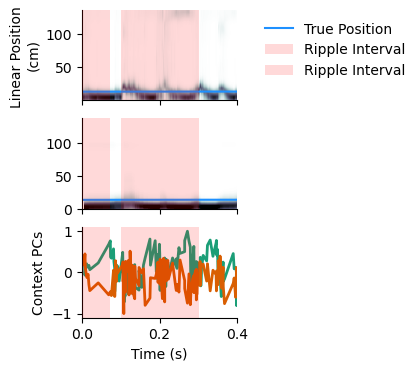

In [14]:
pc_inds = [0, 1]

fig, ax = plt.subplots(
    nrows=3,
    sharex=True,
    height_ratios=[1, 1, 1],
    figsize=(2, 4),
)



xx, yy = np.meshgrid(t_pred_ripple[ind_pred] - st, feature_bins_ripple)
ax[1].pcolormesh(
    xx, yy, feature_posterior_ripple[ind_pred].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
    rasterized=True
)

pos_t = pos_df.index.values
ind_pos = np.logical_and(
    pos_t >= st,
    pos_t <= en,
)
for a in ax[:2]:
    a.plot(
        pos_t[ind_pos] - st,
        pos_df.linear_position[ind_pos],
        c="dodgerblue",
        # s=10,
        label="True Position",
    )


# ind_context = np.logical_and(
#     analysis.t_interp >= st,
#     analysis.t_interp <= en,
# )
# c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
# if len(c_plot.shape) == 1:
#     c_plot = c_plot[:, None]
# c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

ind_context = np.logical_and(
    analysis.t >= st,
    analysis.t <= en,
)
c_plot = analysis.c_pca[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]


c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    plt.plot(
        analysis.t[ind_context] - st,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=2,
        color = plt.cm.Dark2(pc_inds[j] / 8)
    )


for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[-1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position \n(cm)")
ax[-1].set_ylabel("Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])



ind_decode = np.logical_and(
    eric_decode_time >= st,
    eric_decode_time <= en,
)
# ax[0].plot(
#     decode_time[ind_decode] - st,
#     decode_pos[ind_decode],
#     c="orange",
#     label="Eric's Clusterless Decoding",
# )

ax[0].imshow(
    eric_posterior[ind_decode].T,
    aspect="auto",
    origin="lower",
    cmap="bone_r",
    extent=[0, en - st, eric_results.position.min(), eric_results.position.max()],
    zorder=-10,
    rasterized=True
)

for ripple in ripple_intervals:
    # if ripple[0] > st and ripple[1] < en:
    #     for a in ax:
    #         a.axvline(ripple[0] - st, color="r", ls="--")
    #         a.axvline(ripple[1] - st, color="r", ls="--")

    if ripple[1] < st or ripple[0] > en:
        continue
    for a in ax:
        ylim = a.get_ylim()
        a.fill_between(
            [ripple[0] - st, ripple[1] - st],
            ylim[0],
            ylim[1],
            facecolor="r",
            alpha=0.15,
            zorder=20,
            label = "Ripple Interval"
        )
        a.set_ylim(ylim)
    # for r in np.ravel(ripple):
        # if r >= st and r <= en:
        #     for a in ax:
        #         a.axvline(r - st, color="r", ls="--")

ax[0].legend(frameon=False, bbox_to_anchor=(1.1, 1), loc="upper left")
# ax[1].legend(loc="upper left")

# plt.xlim(.8,1.2)
# fig.savefig(
#     fig_dir / f"example_ripple_decode_and_model_comparison_ripple_{i}.svg",
# )

### Compare ripple and trial

In [16]:
# Left example
i_trial = 51
t_rng = -0.1, 0.3
direction="left"

interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i_trial]
ripple_interval_i = interval.copy()
st = interval[0] + t_rng[0]
en = interval[1] + t_rng[1]
ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
pos_pred = feature_pred_ripple[ind_pred]

interval_trial = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
interval_trial = interval_trial[5]
st_trial = interval_trial[0] + t_rng[0]
en_trial = interval_trial[1] + t_rng[1]
ind_pred_trial = np.logical_and(t_pred_ripple >= st_trial, t_pred_ripple <= en_trial)
pos_pred_trial = feature_pred_ripple[ind_pred_trial]


# # Right example
# direction="right"
# i_trial = 4
# t_rng = -0.1, 0.3

# interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
# interval = interval[i_trial]
# ripple_interval_i = interval.copy()
# st = interval[0] + t_rng[0]
# en = interval[1] + t_rng[1]
# ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
# pos_pred = feature_pred_ripple[ind_pred]

# interval_trial = [i_ for i_ in right_running_intervals if i_[1] - i_[0] > 1]
# interval_trial = interval_trial[7]
# st_trial = interval_trial[0] + t_rng[0]
# en_trial = interval_trial[1] + t_rng[1]
# ind_pred_trial = np.logical_and(t_pred_ripple >= st_trial, t_pred_ripple <= en_trial)
# pos_pred_trial = feature_pred_ripple[ind_pred_trial]

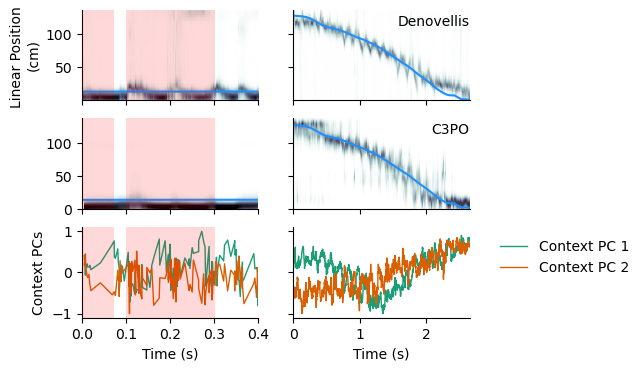

In [18]:
pc_inds = [0, 1]

fig, ax_array = plt.subplots(
    nrows=3,
    ncols=2,
    sharex='col',
    sharey='row',
    height_ratios=[1, 1, 1],
    figsize=(5, 4),
)
ax = ax_array[:,0]


xx, yy = np.meshgrid(t_pred_ripple[ind_pred] - st, feature_bins_ripple)
ax[1].pcolormesh(
    xx, yy, feature_posterior_ripple[ind_pred].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
    rasterized=True
)

pos_t = pos_df.index.values
ind_pos = np.logical_and(
    pos_t >= st,
    pos_t <= en,
)
for a in ax[:2]:
    a.plot(
        pos_t[ind_pos] - st,
        pos_df.linear_position[ind_pos],
        c="dodgerblue",
        # s=10,
        label="True Position",
    )


# ind_context = np.logical_and(
#     analysis.t_interp >= st,
#     analysis.t_interp <= en,
# )
# c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
# if len(c_plot.shape) == 1:
#     c_plot = c_plot[:, None]
# c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

ind_context = np.logical_and(
    analysis.t >= st,
    analysis.t <= en,
)
c_plot = analysis.c_pca[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]


c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    ax[-1].plot(
        analysis.t[ind_context] - st,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=1,
        color = plt.cm.Dark2(pc_inds[j] / 8)
    )


for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[-1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position \n(cm)")
ax[-1].set_ylabel("Context PCs")
ax[0].set_xlim(0, t_rng[1] - t_rng[0])



ind_decode = np.logical_and(
    eric_decode_time >= st,
    eric_decode_time <= en,
)
# ax[0].plot(
#     decode_time[ind_decode] - st,
#     decode_pos[ind_decode],
#     c="orange",
#     label="Eric's Clusterless Decoding",
# )

ax[0].imshow(
    eric_posterior[ind_decode].T,
    aspect="auto",
    origin="lower",
    cmap="bone_r",
    extent=[0, en - st, eric_results.position.min(), eric_results.position.max()],
    zorder=-10,
    rasterized=True
)

for ripple in ripple_intervals:
    # if ripple[0] > st and ripple[1] < en:
    #     for a in ax:
    #         a.axvline(ripple[0] - st, color="r", ls="--")
    #         a.axvline(ripple[1] - st, color="r", ls="--")

    if ripple[1] < st or ripple[0] > en:
        continue
    for a in ax:
        ylim = a.get_ylim()
        a.fill_between(
            [ripple[0] - st, ripple[1] - st],
            ylim[0],
            ylim[1],
            facecolor="r",
            alpha=0.15,
            zorder=20,
            label = "Ripple Interval"
        )
        a.set_ylim(ylim)
    # for r in np.ravel(ripple):
        # if r >= st and r <= en:
        #     for a in ax:
        #         a.axvline(r - st, color="r", ls="--")


###################################################################
########## Trials
################################################################
smooth_context = 11
ax_trial = ax_array[:, 1]
ind_context = np.logical_and(
    analysis.t >= st_trial,
    analysis.t <= en_trial,
)
c_plot = analysis.c_pca[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

from scipy.ndimage import uniform_filter1d
c_plot = uniform_filter1d(c_plot, smooth_context, axis=0)
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    ax_trial[-1].plot(
        analysis.t[ind_context] - st_trial,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=1,
        color = plt.cm.Dark2(pc_inds[j] / 8)
    )

xx, yy = np.meshgrid(t_pred_ripple[ind_pred_trial] - st_trial, feature_bins_ripple)
ax_trial[1].pcolormesh(
    xx, yy, feature_posterior_ripple[ind_pred_trial].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
    rasterized=True
)

pos_t = pos_df.index.values
ind_pos = np.logical_and(
    pos_t >= st_trial,
    pos_t <= en_trial,
)
for a in ax_trial[:2]:
    a.plot(
        pos_t[ind_pos] - st_trial,
        pos_df.linear_position[ind_pos],
        c="dodgerblue",
        # s=10,
        label="True Position",
    )

ind_decode = np.logical_and(
    eric_decode_time >= st_trial,
    eric_decode_time <= en_trial,
)

ax_trial[0].imshow(
    eric_posterior[ind_decode].T,
    aspect="auto",
    origin="lower",
    cmap="bone_r",
    extent=[0, en_trial - st_trial, eric_results.position.min(), eric_results.position.max()],
    zorder=-10,
    rasterized=True
)
ax_trial[-1].set_xlabel("Time (s)")
for a in ax_trial:
    a.spines[['top','right']].set_visible(False)













ax_trial[-1].legend(frameon=False, bbox_to_anchor=(1.1, 1), loc="upper left")

labels = ["Denovellis", "C3PO"]
for i, label in enumerate(labels):
    ylim = ax_trial[i].get_ylim()
    xlim = ax_trial[i].get_xlim()
    ax_trial[i].text(xlim[1], ylim[1]*(.95 if direction=="left" else .05), label,
                     ha="right", va=("top" if direction=="left" else "bottom")
    )
# ax[1].legend(loc="upper left")

# plt.xlim(.8,1.2)
# fig.savefig(
#     fig_dir / f"example_ripple_run_comparison_ripple_{direction}_{i_trial}.svg",
# )

### Compare ripple and trial ( For Figure)

In [83]:
example_dict = {}

# Left example
i_trial = 51
t_rng = -0.1, 0.3
# t_rng = -.5,.5
direction="left"

interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i_trial]
ripple_interval_i = interval.copy()
st = interval[0] + t_rng[0]
en = interval[1] + t_rng[1]
ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
pos_pred = feature_pred_ripple[ind_pred]

interval_trial = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
interval_trial = interval_trial[5]
st_trial = interval_trial[0] + t_rng[0]
en_trial = interval_trial[1] + t_rng[1]
ind_pred_trial = np.logical_and(t_pred_ripple >= st_trial, t_pred_ripple <= en_trial)
pos_pred_trial = feature_pred_ripple[ind_pred_trial]

example_ = {
    "i_trial": i_trial,
    "t_rng": t_rng,
    "direction": direction,
    "ripple_interval": ripple_interval_i,
    "predicted_positions": pos_pred,
    "predicted_positions_trial": pos_pred_trial,
    "st": st,
    "en": en,
    "st_trial": st_trial,
    "en_trial": en_trial,
    "interval_trial": interval_trial,
    "ind_pos_trial": ind_pred_trial,
}
example_dict["left"] = example_

# Right example
direction="right"
i_trial = 4
# t_rng = -0.1, 0.3

interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i_trial]
ripple_interval_i = interval.copy()
st = interval[0] + t_rng[0]
en = interval[1] + t_rng[1]
ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
pos_pred = feature_pred_ripple[ind_pred]

interval_trial = [i_ for i_ in right_running_intervals if i_[1] - i_[0] > 1]
interval_trial = interval_trial[7]
st_trial = interval_trial[0] + t_rng[0]
en_trial = interval_trial[1] + t_rng[1]
ind_pred_trial = np.logical_and(t_pred_ripple >= st_trial, t_pred_ripple <= en_trial)
pos_pred_trial = feature_pred_ripple[ind_pred_trial]

example_ = {
    "i_trial": i_trial,
    "t_rng": t_rng,
    "direction": direction,
    "ripple_interval": ripple_interval_i,
    "predicted_positions": pos_pred,
    "predicted_positions_trial": pos_pred_trial,
    "st": st,
    "en": en,
    "st_trial": st_trial,
    "en_trial": en_trial,
    "interval_trial": interval_trial,
    "ind_pos_trial": ind_pred_trial,
}
example_dict["right"] = example_

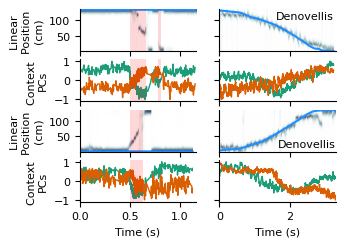

In [55]:
pc_inds = [0, 1]

fig, ax_array_all = plt.subplots(
    nrows=4,
    ncols=2,
    sharex='col',
    sharey='row',
    height_ratios=[1, 1, 1, 1],
    figsize=(3.3, 2.5),
)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8

ax_groups = [ax_array_all[:2], ax_array_all[2:]]

for example, ax_array in zip(example_dict.values(), ax_groups):
    i_trial = example["i_trial"]
    t_rng = example["t_rng"]
    direction = example["direction"]
    ripple_interval_i = example["ripple_interval"]
    pos_pred = example["predicted_positions"]
    pos_pred_trial = example["predicted_positions_trial"]
    st = example["st"]
    en = example["en"]
    st_trial = example["st_trial"]
    en_trial = example["en_trial"]
    interval_trial = example["interval_trial"]
    ind_pred_trial = example["ind_pos_trial"]


    ax = ax_array[:,0]


    # xx, yy = np.meshgrid(t_pred_ripple[ind_pred] - st, feature_bins_ripple)
    # ax[1].pcolormesh(
    #     xx, yy, feature_posterior_ripple[ind_pred].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
    #     rasterized=True
    # )

    pos_t = pos_df.index.values
    ind_pos = np.logical_and(
        pos_t >= st,
        pos_t <= en,
    )
    for a in [ax[0]]:
        a.plot(
            pos_t[ind_pos] - st,
            pos_df.linear_position[ind_pos],
            c="dodgerblue",
            # s=10,
            label="True Position",
        )


    # ind_context = np.logical_and(
    #     analysis.t_interp >= st,
    #     analysis.t_interp <= en,
    # )
    # c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
    # if len(c_plot.shape) == 1:
    #     c_plot = c_plot[:, None]
    # c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

    ind_context = np.logical_and(
        analysis.t >= st,
        analysis.t <= en,
    )
    c_plot = analysis.c_pca[ind_context][:, pc_inds]
    if len(c_plot.shape) == 1:
        c_plot = c_plot[:, None]


    c_plot = c_plot - np.mean(c_plot, axis=0)
    c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
    for j in range(c_plot.shape[1]):
        ax[-1].plot(
            analysis.t[ind_context] - st,
            c_plot[:, j],
            zorder=-1,
            label=f"Context PC {j+1}",
            lw=1,
            color = plt.cm.Dark2(pc_inds[j] / 8)
        )


    for a in ax:
        a.spines[["top", "right"]].set_visible(False)

    ax[-1].set_xlabel("Time (s)")
    ax[0].set_ylabel("Linear \nPosition \n(cm)")
    ax[-1].set_ylabel("Context \nPCs")
    # ax[0].set_xlim(0, t_rng[1] - t_rng[0])



    ind_decode = np.logical_and(
        eric_decode_time >= st,
        eric_decode_time <= en,
    )
    # ax[0].plot(
    #     decode_time[ind_decode] - st,
    #     decode_pos[ind_decode],
    #     c="orange",
    #     label="Eric's Clusterless Decoding",
    # )

    ax[0].imshow(
        eric_posterior[ind_decode].T,
        aspect="auto",
        origin="lower",
        cmap="bone_r",
        extent=[0, en - st, eric_results.position.min(), eric_results.position.max()],
        zorder=-10,
        rasterized=True
    )

    for ripple in ripple_intervals:
        # if ripple[0] > st and ripple[1] < en:
        #     for a in ax:
        #         a.axvline(ripple[0] - st, color="r", ls="--")
        #         a.axvline(ripple[1] - st, color="r", ls="--")

        if ripple[1] < st or ripple[0] > en:
            continue
        for a in ax:
            ylim = a.get_ylim()
            a.fill_between(
                [ripple[0] - st, ripple[1] - st],
                ylim[0],
                ylim[1],
                facecolor="r",
                alpha=0.15,
                zorder=20,
                label = "Ripple Interval"
            )
            a.set_ylim(ylim)
        # for r in np.ravel(ripple):
            # if r >= st and r <= en:
            #     for a in ax:
            #         a.axvline(r - st, color="r", ls="--")


    ###################################################################
    ########## Trials
    ################################################################
    smooth_context = 11
    ax_trial = ax_array[:, 1]
    ind_context = np.logical_and(
        analysis.t >= st_trial,
        analysis.t <= en_trial,
    )
    c_plot = analysis.c_pca[ind_context][:, pc_inds]
    if len(c_plot.shape) == 1:
        c_plot = c_plot[:, None]

    from scipy.ndimage import uniform_filter1d
    c_plot = uniform_filter1d(c_plot, smooth_context, axis=0)
    c_plot = c_plot - np.mean(c_plot, axis=0)
    c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
    for j in range(c_plot.shape[1]):
        ax_trial[-1].plot(
            analysis.t[ind_context] - st_trial,
            c_plot[:, j],
            zorder=-1,
            label=f"Context PC {j+1}",
            lw=1,
            color = plt.cm.Dark2(pc_inds[j] / 8)
        )

    # xx, yy = np.meshgrid(t_pred_ripple[ind_pred_trial] - st_trial, feature_bins_ripple)
    # ax_trial[1].pcolormesh(
    #     xx, yy, feature_posterior_ripple[ind_pred_trial].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
    #     rasterized=True
    # )

    pos_t = pos_df.index.values
    ind_pos = np.logical_and(
        pos_t >= st_trial,
        pos_t <= en_trial,
    )
    for a in [ax_trial[0]]:
        a.plot(
            pos_t[ind_pos] - st_trial,
            pos_df.linear_position[ind_pos],
            c="dodgerblue",
            # s=10,
            label="True Position",
        )

    ind_decode = np.logical_and(
        eric_decode_time >= st_trial,
        eric_decode_time <= en_trial,
    )

    ax_trial[0].imshow(
        eric_posterior[ind_decode].T,
        aspect="auto",
        origin="lower",
        cmap="bone_r",
        extent=[0, en_trial - st_trial, eric_results.position.min(), eric_results.position.max()],
        zorder=-10,
        rasterized=True
    )
    ax_trial[-1].set_xlabel("Time (s)")
    for a in ax_trial:
        a.spines[['top','right']].set_visible(False)















    labels = ["Denovellis", ]#"C3PO"]
    for i, label in enumerate(labels):
        ylim = ax_trial[i].get_ylim()
        xlim = ax_trial[i].get_xlim()
        ax_trial[i].text(xlim[1], ylim[1]*(.95 if direction=="left" else .05), label,
                        ha="right", va=("top" if direction=="left" else "bottom")
        )

# ax_trial[-1].legend(frameon=False, bbox_to_anchor=(1.1, 1), loc="upper left")
# ax[1].legend(loc="upper left")

# plt.xlim(.8,1.2){
# fig.savefig(
#     fig_dir / f"example_ripple_run_comparison_ripple_FIGURE.svg",
# )

## V2: With c3po decode and ripple band

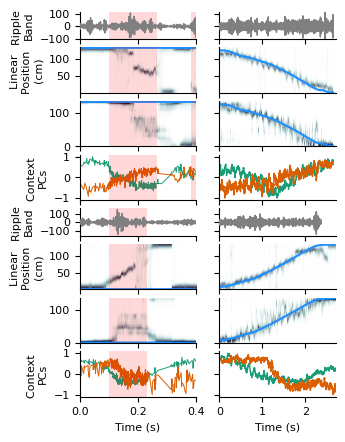

In [ ]:
pc_inds = [0, 1]
rip_band_color = "grey"
rip_lw = 1

fig, ax_array_all = plt.subplots(
    nrows=8,
    ncols=2,
    sharex='col',
    sharey='row',
    height_ratios=[.6, 1, 1, 1]*2,
    figsize=(3.3, 5),
)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8

ax_groups = [ax_array_all[:4], ax_array_all[4:]]

for example, ax_array in zip(example_dict.values(), ax_groups):
    i_trial = example["i_trial"]
    t_rng = example["t_rng"]
    direction = example["direction"]
    ripple_interval_i = example["ripple_interval"]
    pos_pred = example["predicted_positions"]
    pos_pred_trial = example["predicted_positions_trial"]
    st = example["st"]
    en = example["en"]
    st_trial = example["st_trial"]
    en_trial = example["en_trial"]
    interval_trial = example["interval_trial"]
    ind_pred_trial = example["ind_pos_trial"]


    ax = ax_array[:,0]

    ind_ripple = np.logical_and(rip_band_obj.timestamps >= st, rip_band_obj.timestamps <= en)
    ax[0].plot(
        rip_band_obj.timestamps[ind_ripple] - st,
        rip_band_obj.data[ind_ripple,19],
        lw=rip_lw,
        c=rip_band_color,
        zorder = 20
    )


    ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
    xx, yy = np.meshgrid(t_pred_ripple[ind_pred] - st, feature_bins_ripple)
    ax[2].pcolormesh(
        xx, yy, feature_posterior_ripple[ind_pred].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
        rasterized=True
    )

    pos_t = pos_df.index.values
    ind_pos = np.logical_and(
        pos_t >= st,
        pos_t <= en,
    )
    for a in ax[1:3]:
        a.plot(
            pos_t[ind_pos] - st,
            pos_df.linear_position[ind_pos],
            c="dodgerblue",
            # s=10,
            label="True Position",
        )


    # ind_context = np.logical_and(
    #     analysis.t_interp >= st,
    #     analysis.t_interp <= en,
    # )
    # c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
    # if len(c_plot.shape) == 1:
    #     c_plot = c_plot[:, None]
    # c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

    ind_context = np.logical_and(
        analysis.t >= st,
        analysis.t <= en,
    )
    c_plot = analysis.c_pca[ind_context][:, pc_inds]
    if len(c_plot.shape) == 1:
        c_plot = c_plot[:, None]


    c_plot = c_plot - np.mean(c_plot, axis=0)
    c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
    for j in range(c_plot.shape[1]):
        ax[-1].plot(
            analysis.t[ind_context] - st,
            c_plot[:, j],
            zorder=-1,
            label=f"Context PC {j+1}",
            lw=.7,
            color = plt.cm.Dark2(pc_inds[j] / 8)
        )


    for a in ax:
        a.spines[["top", "right"]].set_visible(False)

    ax[-1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Linear \nPosition \n(cm)")
    ax[-1].set_ylabel("Context \nPCs")
    ax[0].set_ylabel("Ripple \nBand")
    # ax[0].set_xlim(0, t_rng[1] - t_rng[0])



    ind_decode = np.logical_and(
        eric_decode_time >= st,
        eric_decode_time <= en,
    )

    ax[1].imshow(
        eric_posterior[ind_decode].T,
        aspect="auto",
        origin="lower",
        cmap="bone_r",
        extent=[0, en - st, eric_results.position.min(), eric_results.position.max()],
        zorder=-10,
        rasterized=True
    )




    for ripple in ripple_intervals:
        # if ripple[0] > st and ripple[1] < en:
        #     for a in ax:
        #         a.axvline(ripple[0] - st, color="r", ls="--")
        #         a.axvline(ripple[1] - st, color="r", ls="--")

        if ripple[1] < st or ripple[0] > en:
            continue
        for i,a in enumerate(ax):
            if i == 0:
                zorder = -10
            else:
                zorder = 20
            ylim = a.get_ylim()
            a.fill_between(
                [ripple[0] - st, ripple[1] - st],
                ylim[0],
                ylim[1],
                facecolor="r",
                alpha=0.15,
                zorder=zorder,
                label = "Ripple Interval"
            )
            a.set_ylim(ylim)
        # for r in np.ravel(ripple):
            # if r >= st and r <= en:
            #     for a in ax:
            #         a.axvline(r - st, color="r", ls="--")


    ###################################################################
    ########## Trials
    ################################################################
    smooth_context = 11
    ax_trial = ax_array[:, 1]

    ind_ripple = np.logical_and(rip_band_obj.timestamps >= st_trial, rip_band_obj.timestamps <= en_trial)
    ax_trial[0].plot(
        rip_band_obj.timestamps[ind_ripple] - st_trial,
        rip_band_obj.data[ind_ripple,19],
        lw=rip_lw,
        c=rip_band_color,
        zorder=20
    )



    ind_context = np.logical_and(
        analysis.t >= st_trial,
        analysis.t <= en_trial,
    )
    c_plot = analysis.c_pca[ind_context][:, pc_inds]
    if len(c_plot.shape) == 1:
        c_plot = c_plot[:, None]

    from scipy.ndimage import uniform_filter1d
    c_plot = uniform_filter1d(c_plot, smooth_context, axis=0)
    c_plot = c_plot - np.mean(c_plot, axis=0)
    c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
    for j in range(c_plot.shape[1]):
        ax_trial[-1].plot(
            analysis.t[ind_context] - st_trial,
            c_plot[:, j],
            zorder=-1,
            label=f"Context PC {j+1}",
            lw=1,
            color = plt.cm.Dark2(pc_inds[j] / 8)
        )

    ind_pred_trial = np.logical_and(t_pred_ripple >= st_trial, t_pred_ripple <= en_trial)
    xx, yy = np.meshgrid(t_pred_ripple[ind_pred_trial] - st_trial, feature_bins_ripple)
    ax_trial[2].pcolormesh(
        xx, yy, feature_posterior_ripple[ind_pred_trial].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
        rasterized=True
    )

    pos_t = pos_df.index.values
    ind_pos = np.logical_and(
        pos_t >= st_trial,
        pos_t <= en_trial,
    )
    for a in ax_trial[1:3]:
        a.plot(
            pos_t[ind_pos] - st_trial,
            pos_df.linear_position[ind_pos],
            c="dodgerblue",
            # s=10,
            label="True Position",
        )

    ind_decode = np.logical_and(
        eric_decode_time >= st_trial,
        eric_decode_time <= en_trial,
    )

    ax_trial[1].imshow(
        eric_posterior[ind_decode].T,
        aspect="auto",
        origin="lower",
        cmap="bone_r",
        extent=[0, en_trial - st_trial, eric_results.position.min(), eric_results.position.max()],
        zorder=-10,
        rasterized=True
    )
    ax_trial[-1].set_xlabel("Time (s)")
    for a in ax_trial:
        a.spines[['top','right']].set_visible(False)













ax_array[0,0].set_xlim(0,.4)

    # labels = ["Denovellis", ]#"C3PO"]
    # for i, label in enumerate(labels):
    #     ylim = ax_trial[i].get_ylim()
    #     xlim = ax_trial[i].get_xlim()
    #     ax_trial[i].text(xlim[1], ylim[1]*(.95 if direction=="left" else .05), label,
    #                     ha="right", va=("top" if direction=="left" else "bottom")
    #     )

# ax_trial[-1].legend(frameon=False, bbox_to_anchor=(1.1, 1), loc="upper left")
# ax[1].legend(loc="upper left")

# plt.xlim(.8,1.2){
fig.savefig(
    fig_dir / f"example_ripple_run_comparison_ripple_FIGURE_V2.svg",
)

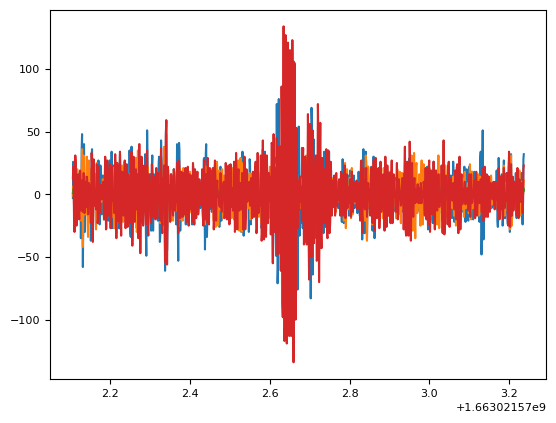

In [76]:
ind_st = np.digitize(st, rip_band_obj.timestamps)
ind_en = np.digitize(en, rip_band_obj.timestamps)
ii = 15
plt.plot(rip_band_obj.timestamps[ind_st:ind_en], rip_band_obj.data[ind_st:ind_en,ii:ii+4],)

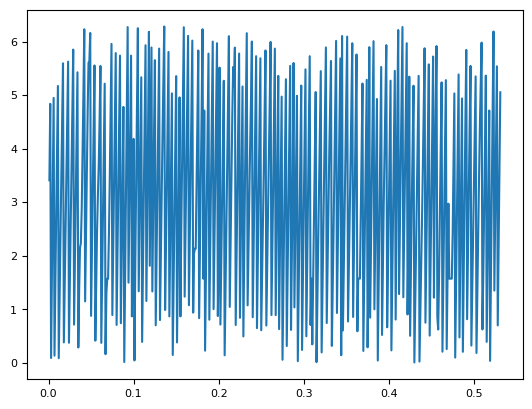

In [48]:
ind_st = np.digitize(st, rip_phase_df.index.values)
ind_en = np.digitize(en, rip_phase_df.index.values)

plt.plot(rip_phase_df.index.values[ind_st:ind_en] - st, rip_phase_df['electrode 12'].values[ind_st:ind_en],)

In [25]:
example

4

In [ ]:
feature_pred_posterior[ind_pred].shape, feature_pred.shape

((423, 70), (723583, 1))

In [21]:
for i in range(100):
    interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
    if i > len(interval) - 1:
        break
    interval = interval[i]
    ripple_interval_i = interval.copy()
    st = interval[0] + t_rng[0]
    en = interval[0] + t_rng[1]

    # pred_t, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
    # t_pred, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
    ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
    pos_pred = feature_pred_ripple[ind_pred]

    fig, ax = plt.subplots(
        nrows=2,
        sharex=True,
        height_ratios=[1, 1],
        figsize=(10, 8),
    )
    fig.suptitle(f"Ripple Interval {i}: {st:.3f} - {en:.3f}")

    # t_ripple = ripple_band_obj.timestamps
    # ind_ripple = np.logical_and(
    #     t_ripple >= st,
    #     t_ripple <= en,
    # )
    # ax[0].plot(
    #     t_ripple[ind_ripple] - st,
    #     ripple_band_obj.data[ind_ripple][:, ref_ind] / 100,
    #     c="k",
    #     lw=2,
    #     zorder=-10,
    #     label="LFP Theta Band",
    # )
    ax[0].plot(
        t_pred_ripple[ind_pred] - st,
        pos_pred,
        c="mediumseagreen",
        label="Decoded Position",
        lw=1,
        alpha=0.75,
        marker="o",
        markersize=3,
        linestyle="",
    )

    pos_t = pos_df.index.values
    ind_pos = np.logical_and(
        pos_t >= st,
        pos_t <= en,
    )
    ax[0].plot(
        pos_t[ind_pos] - st,
        pos_df.linear_position[ind_pos],
        c="cyan",
        # s=10,
        label="True Position",
    )

    # ind_context = np.logical_and(
    #     analysis.t_interp >= st,
    #     analysis.t_interp <= en,
    # )
    # c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
    # if len(c_plot.shape) == 1:
    #     c_plot = c_plot[:, None]
    # c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

    ind_context = np.logical_and(
        analysis.t >= st,
        analysis.t <= en,
    )
    c_plot = analysis.c_pca[ind_context][:, pc_inds]
    if len(c_plot.shape) == 1:
        c_plot = c_plot[:, None]

    c_plot = c_plot - np.mean(c_plot, axis=0)
    c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
    for j in range(c_plot.shape[1]):
        plt.plot(
            analysis.t[ind_context] - st,
            c_plot[:, j],
            zorder=-1,
            label=f"Context PC {j+1}",
            lw=2,
        )

    for a in ax:
        a.spines[["top", "right"]].set_visible(False)

    ax[1].set_xlabel("Time (s)")
    ax[0].set_ylabel("Linear Position \n(cm)")
    ax[1].set_ylabel("Context PCs")
    plt.xlim(0, t_rng[1] - t_rng[0])

    # for t_ in interval:
    #     ax[1].axvline(interval[0] - st, color="red", ls="--")

    for ripple in ripple_intervals:
        # if ripple[0] > st and ripple[1] < en:
        #     for a in ax:
        #         a.axvline(ripple[0] - st, color="r", ls="--")
        #         a.axvline(ripple[1] - st, color="r", ls="--")
        for r in np.ravel(ripple):
            if r >= st and r <= en:
                for a in ax:
                    a.axvline(r - st, color="r", ls="--")

    ind_decode = np.logical_and(
        eric_decode_time >= st,
        eric_decode_time <= en,
    )
    # ax[0].plot(
    #     decode_time[ind_decode] - st,
    #     decode_pos[ind_decode],
    #     c="orange",
    #     label="Eric's Clusterless Decoding",
    # )
    ax[0].imshow(
        eric_posterior[ind_decode].T,
        aspect="auto",
        origin="lower",
        cmap="bone_r",
        extent=[0, en - st, eric_results.position.min(), eric_results.position.max()],
        zorder=-10,
    )

    ax[0].legend(loc="upper left")
    ax[1].legend(loc="upper left")

    sub_dir = fig_dir / f"ripple_decode_and_model_comparison"
    sub_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        sub_dir / f"ripple{i}.svg",
    )
    plt.close(fig)

# Ripple Decoding with orientation

In [10]:
from c3po.analysis.intervals import interval_list_contains_ind
t_feature = pos_df.index.values
feature = pos_df.linear_position.values[:, None]

feature_indicator = np.zeros_like(feature)
ind_right = interval_list_contains_ind(right_running_intervals, t_feature)
feature_indicator[ind_right] = 1
feature = np.concatenate([feature, feature_indicator], axis=1)
feature.shape
# plt.plot(feature[100000:110000, 1])

(630979, 2)

In [ ]:

analysis.initialize_decoder(
    "discretized_regression",
    # n_bins=70,
    max_iter=100,
    # balance_groups=True,
    balance_groups = False,
    multidim=False,
    predict_method="weighted",
    # n_jobs=4,
    environment=environment,
    feature_smooth_std = 4,
    normalize_decode_context = False,
    indicator_discretizer = True,
)

analysis.fit_decoder(
    feature,
    t_feature,
    # intervals=all_running_intervals,
    # pca=True,
    pca = False,
    # decode_dim=1,
    interpolate=False,
    # smooth_context=5,
    smooth_context = 11,
)



0.0 135.82341960824513
(630207, 2) (630207, 20)
0.0 135.82341960824513


In [13]:
pred_interval = np.array([[analysis.t[0], analysis.t[-1]]]).T

t_pred_ripple, (feature_pred_ripple, (feature_posterior_ripple_expanded, feature_bins_ripple_expanded)) = analysis.predict_decoder(
    pred_interval,
    # smooth_context=None,
    smooth_context=3,
    return_posterior=True,
    # interpolate=True,
    # chunk_size=10,
    # subsample=50
)
n_mid = feature_posterior_ripple_expanded.shape[1] // 2
feature_posterior_ripple = feature_posterior_ripple_expanded[:, :n_mid] + feature_posterior_ripple_expanded[:, n_mid:]

In [46]:
# plt.plot(analysis.decoder_model.discretizer.bin_centers[:,1])

feature_bins_ripple = analysis.decoder_model.discretizer.discretizer.bin_centers

In [41]:
# feature_bins_ripple_expanded.shape
# feature_bins_ripple = feature_bins_ripple_expanded[::2,0]


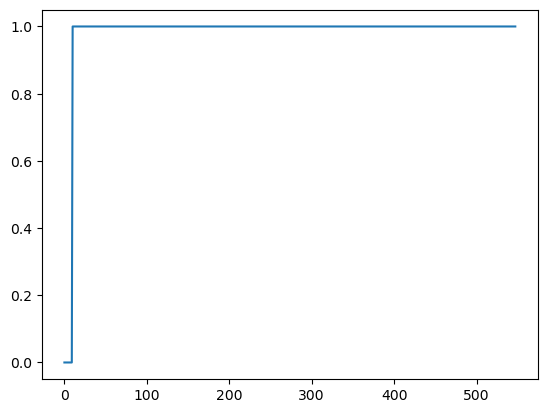

In [42]:
plt.plot(feature_bins_ripple_expanded[:,1])

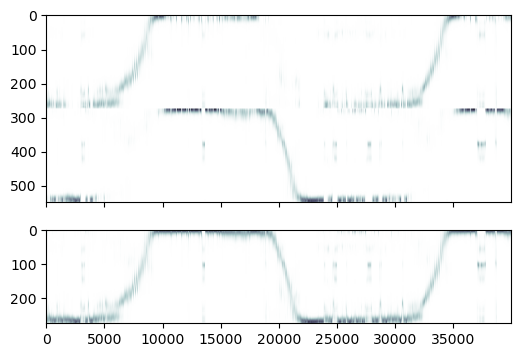

In [ ]:
feature_posterior_ripple

ind = slice(100000, 140000)
# ind = ind_pred

fig, ax = plt.subplots(nrows = 2, height_ratios = [2, 1], sharex=True, figsize=(6,4))
# xx, yy = np.meshgrid(t_pred_ripple[ind] - st, feature_bins_ripple_expanded[:,0])
ax[0].imshow(
    feature_posterior_ripple_expanded[ind].T,
    aspect='auto',
    cmap = "bone_r"
)
# ax[0].pcolormesh(
#     xx, yy, feature_posterior_ripple_expanded[ind].T, cmap="bone_r", shading="auto", zorder=-20,
#     rasterized=True
# )
ax[1].imshow(
    feature_posterior_ripple[ind].T,
    aspect='auto',
    cmap = "bone_r"
)

In [74]:
i = 4
t_rng = -0.1, 0.3

# t_rng = -1,1
i = 42
i = 29
t_rng = -0.25, 0.35

interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i]

# # analysis = analysis_all
# t_rng = (0,2)
# interval = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
# interval = interval[5]



ripple_interval_i = interval.copy()
st = interval[0] + t_rng[0]
en = interval[1] + t_rng[1]

# pred_t, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
# t_pred, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
pos_pred = feature_pred_ripple[ind_pred]

# plt.plot(t_pred[ind_pred] - st, pos_pred[ind_pred], c="mediumseagreen", label="Decoded Position")
# plt.plot(pred_t - st, pos_pred, c="mediumseagreen", label="Decoded Position")

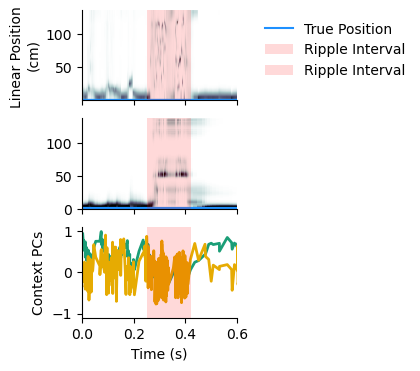

In [75]:
pc_inds = [0, 5]

fig, ax = plt.subplots(
    nrows=3,
    sharex=True,
    height_ratios=[1, 1, 1],
    figsize=(2, 4),
)



xx, yy = np.meshgrid(t_pred_ripple[ind_pred] - st, feature_bins_ripple)
ax[1].pcolormesh(
    xx, yy, feature_posterior_ripple[ind_pred].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
    rasterized=True
)

pos_t = pos_df.index.values
ind_pos = np.logical_and(
    pos_t >= st,
    pos_t <= en,
)
for a in ax[:2]:
    a.plot(
        pos_t[ind_pos] - st,
        pos_df.linear_position[ind_pos],
        c="dodgerblue",
        # s=10,
        label="True Position",
    )


# ind_context = np.logical_and(
#     analysis.t_interp >= st,
#     analysis.t_interp <= en,
# )
# c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
# if len(c_plot.shape) == 1:
#     c_plot = c_plot[:, None]
# c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

ind_context = np.logical_and(
    analysis.t >= st,
    analysis.t <= en,
)
c_plot = analysis.c_pca[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]


c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    plt.plot(
        analysis.t[ind_context] - st,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=2,
        color = plt.cm.Dark2(pc_inds[j] / 8)
    )


for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[-1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position \n(cm)")
ax[-1].set_ylabel("Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])



ind_decode = np.logical_and(
    eric_decode_time >= st,
    eric_decode_time <= en,
)
# ax[0].plot(
#     decode_time[ind_decode] - st,
#     decode_pos[ind_decode],
#     c="orange",
#     label="Eric's Clusterless Decoding",
# )

ax[0].imshow(
    eric_posterior[ind_decode].T,
    aspect="auto",
    origin="lower",
    cmap="bone_r",
    extent=[0, en - st, eric_results.position.min(), eric_results.position.max()],
    zorder=-10,
    rasterized=True
)

for ripple in ripple_intervals:
    # if ripple[0] > st and ripple[1] < en:
    #     for a in ax:
    #         a.axvline(ripple[0] - st, color="r", ls="--")
    #         a.axvline(ripple[1] - st, color="r", ls="--")

    if ripple[1] < st or ripple[0] > en:
        continue
    for a in ax:
        ylim = a.get_ylim()
        a.fill_between(
            [ripple[0] - st, ripple[1] - st],
            ylim[0],
            ylim[1],
            facecolor="r",
            alpha=0.15,
            zorder=20,
            label = "Ripple Interval"
        )
        a.set_ylim(ylim)
    # for r in np.ravel(ripple):
        # if r >= st and r <= en:
        #     for a in ax:
        #         a.axvline(r - st, color="r", ls="--")

ax[0].legend(frameon=False, bbox_to_anchor=(1.1, 1), loc="upper left")
# ax[1].legend(loc="upper left")

# plt.xlim(.8,1.2)
# fig.savefig(
#     fig_dir / f"example_ripple_decode_and_model_comparison_ripple_{i}.svg",
# )

# Ripple Decoding 2d

In [ ]:
from spyglass.position.v1 import TrodesPosV1
epoch_key = {
    "nwb_file_name": nwb_file_name,
    "interval_list_name": epoch_interval,
}
pos_interval = (PositionIntervalMap() & epoch_key).fetch1("position_interval_name")
pos_key = {
    "nwb_file_name": nwb_file_name,
    "interval_list_name": pos_interval,
    "trodes_pos_params_name": "single_led_upsampled",
}
pos_df_2d = (TrodesPosV1() & pos_key).fetch1_dataframe()

[12:47:55][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: Us

In [405]:
t_feature = pos_df_2d.index.values
feature = pos_df_2d[["position_x","position_y"]].values

# analysis.initialize_decoder(
#     "knn",
#     n_neighbors=30,
#     weights="distance",
# )
analysis.initialize_decoder(
    "discretized_regression",
    # n_bins=70,
    max_iter=100,
    # balance_groups=True,
    balance_groups = False,
    multidim=True,
    predict_method="weighted",
    n_bins = (100,50),
    # n_jobs=4,
    # environment=environment,
    # feature_smooth_std = 4,
    # fit_intervals=all_running_intervals
)

analysis.fit_decoder(
    feature,
    t_feature,
    # intervals=all_running_intervals,
    pca=True,
    # decode_dim=1,
    interpolate=False,
    smooth_context=5,
)

# t_pred_list, feature_pred_list = analysis.cross_validated_decoding(
#     feature,
#     t_feature,
#     # intervals=all_running_intervals,
#     pca=True,
#     # decode_dim=1,
#     interpolate=False,
#     return_posterior=True,
#     smooth_context=5,
# )
# t_pred = np.concatenate(t_pred_list)
# feature_pred = np.concatenate([f[0] for f in feature_pred_list])
# feature_pred_posterior = np.concatenate([f[1][0] for f in feature_pred_list])
# feature_pred_bins = feature_pred_list[0][1][1]

# hd_t_pred = t_pred
# hd_pred = feature_pred[:, 0]

20.519999999999985 194.64000000000013
(630222, 2) (630222, 20)
20.519999999999985 194.64000000000013
(630222, 2)
Attempting full fit...


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jax/_src/interpreters/mlir.py:1135: UserWarning: A large amount of constants were captured during lowering (3.19GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


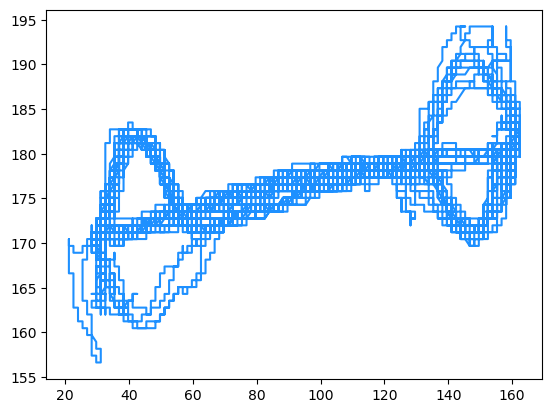

In [406]:
discretizer = analysis.decoder_model.discretizer

ordinal_feature = discretizer.transform(feature)
# discretizer.discretizers[0].bin_edges_
recover_feature = discretizer.inverse_transform(ordinal_feature)

plt.plot(recover_feature[:,0], recover_feature[:,1], c="dodgerblue", label="True Position")

In [407]:
pred_interval = np.array([[analysis.t[0], analysis.t[-1]]]).T
(
    t_pred_ripple,
    (feature_pred_ripple_2d, (feature_posterior_ripple_expanded, feature_bins_ripple))
    ) = analysis.predict_decoder(
    pred_interval,
    # smooth_context=None,
    smooth_context=3,
    return_posterior=True,
    # interpolate=True,
    # chunk_size=10,
    # subsample=50
)

feature_pred_ripple_2d = np.squeeze(feature_pred_ripple_2d)
from track_linearization import get_linearized_position
feature_pred_ripple = get_linearized_position(
            position=feature_pred_ripple_2d,
            track_graph=environment.track_graph,
            edge_order=environment.edge_order,
            edge_spacing=environment.edge_spacing,
        ).linear_position.values

linearized_2d_bin_centers = get_linearized_position(
    position=analysis.decoder_model.discretizer.bin_centers,
    track_graph=environment.track_graph,
    edge_order=environment.edge_order,
    edge_spacing=environment.edge_spacing,
).linear_position.values

updated_pred


In [ ]:
bx = analysis.decoder_model.discretizer.discretizers[0].bin_edges_[0][:-1]
by = analysis.decoder_model.discretizer.discretizers[1].bin_edges_[0][:-1]

i = 105000
p = np.zeros((len(bx), len(by)))
for j in range(feature_posterior_ripple_expanded.shape[1]):
    xy = analysis.decoder_model.discretizer.bin_centers[j]
    x_ind = np.digitize(xy[0], bx) - 1
    y_ind = np.digitize(xy[1], by) - 1
    p[x_ind, y_ind] += feature_posterior_ripple_expanded[i][j]



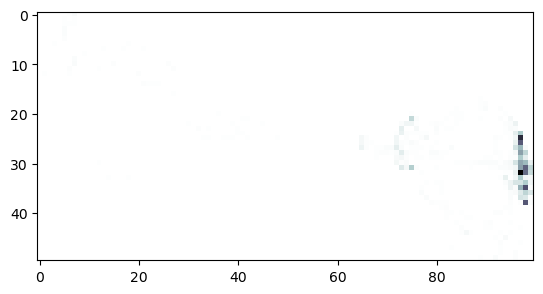

In [436]:
plt.imshow(p.T,cmap = "bone_r")

In [408]:
linear_bin_edges = np.arange(
    pos_df.linear_position.min(),
    pos_df.linear_position.max(),
    3
)
linear_bin_centers = (linear_bin_edges[:-1] + linear_bin_edges[1:]) / 2
print(linear_bin_edges.size)
linear_bin_map = np.digitize(linearized_2d_bin_centers, linear_bin_centers, right=True)-1

feature_posterior_ripple = np.zeros((feature_posterior_ripple_expanded.shape[0], linear_bin_centers.size))
for i in range (feature_posterior_ripple_expanded.shape[1]):
    feature_posterior_ripple[:, linear_bin_map[i]] += feature_posterior_ripple_expanded[:, i]



46


In [409]:
linear_bin_map.max(), linear_bin_edges.size, pos_df.linear_position.max(),
linear_bin_edges.shape, ind_pred.shape, t_pred_ripple.shape, t_pred_ripple.shape
# t_pred_ripple[ind_pred]# - st

((46,), (723578,), (723578,), (723578,))

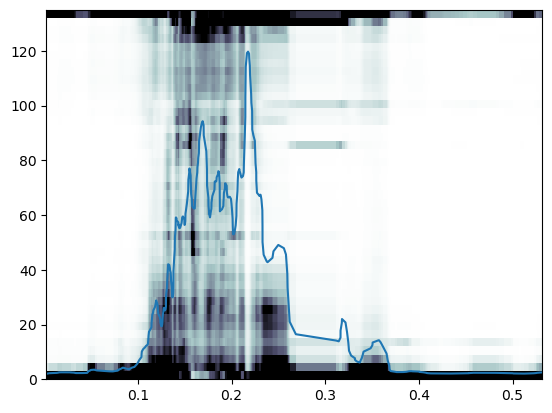

In [410]:
# plt.plot(feature_pred_ripple[ind,0], feature_pred_ripple[ind,1], c="mediumseagreen", label="Decoded Position")
xx, yy = np.meshgrid(t_pred_ripple[ind_pred] - st, linear_bin_edges)
plt.pcolormesh(
    xx, yy, feature_posterior_ripple[ind_pred][1:].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
    rasterized=True
)

plt.plot(t_pred_ripple[ind_pred] - st,feature_pred_ripple[ind_pred])


In [402]:
i = 4
t_rng = -0.1, 0.3

# t_rng = -1,1
# i = 42
# i = 25
# t_rng = -0.25, 0.35

interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i]
ripple_interval_i = interval.copy()
st = interval[0] + t_rng[0]
en = interval[1] + t_rng[1]

# pred_t, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
# t_pred, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
ind_pred = np.logical_and(t_pred_ripple >= st, t_pred_ripple <= en)
pos_pred = feature_pred_ripple[ind_pred]

# plt.plot(t_pred[ind_pred] - st, pos_pred[ind_pred], c="mediumseagreen", label="Decoded Position")
# plt.plot(pred_t - st, pos_pred, c="mediumseagreen", label="Decoded Position")

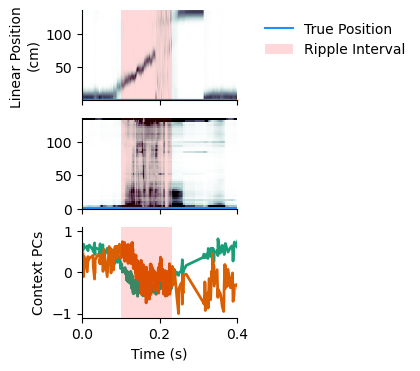

In [404]:
pc_inds = [0, 1]

fig, ax = plt.subplots(
    nrows=3,
    sharex=True,
    height_ratios=[1, 1, 1],
    figsize=(2, 4),
)



xx, yy = np.meshgrid(t_pred_ripple[ind_pred] - st, linear_bin_centers)
ax[1].pcolormesh(
    xx, yy, feature_posterior_ripple[ind_pred].T, cmap="bone_r", shading="auto", zorder=-20, vmin=0, vmax=0.05,
    rasterized=True
)

pos_t = pos_df.index.values
ind_pos = np.logical_and(
    pos_t >= st,
    pos_t <= en,
)
for a in ax[:2]:
    a.plot(
        pos_t[ind_pos] - st,
        pos_df.linear_position[ind_pos],
        c="dodgerblue",
        # s=10,
        label="True Position",
    )


# ind_context = np.logical_and(
#     analysis.t_interp >= st,
#     analysis.t_interp <= en,
# )
# c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
# if len(c_plot.shape) == 1:
#     c_plot = c_plot[:, None]
# c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")

ind_context = np.logical_and(
    analysis.t >= st,
    analysis.t <= en,
)
c_plot = analysis.c_pca[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]


c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    plt.plot(
        analysis.t[ind_context] - st,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=2,
        color = plt.cm.Dark2(pc_inds[j] / 8)
    )


for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[-1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position \n(cm)")
ax[-1].set_ylabel("Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])



ind_decode = np.logical_and(
    eric_decode_time >= st,
    eric_decode_time <= en,
)
# ax[0].plot(
#     decode_time[ind_decode] - st,
#     decode_pos[ind_decode],
#     c="orange",
#     label="Eric's Clusterless Decoding",
# )

ax[0].imshow(
    eric_posterior[ind_decode].T,
    aspect="auto",
    origin="lower",
    cmap="bone_r",
    extent=[0, en - st, eric_results.position.min(), eric_results.position.max()],
    zorder=-10,
    rasterized=True
)

for ripple in ripple_intervals:
    # if ripple[0] > st and ripple[1] < en:
    #     for a in ax:
    #         a.axvline(ripple[0] - st, color="r", ls="--")
    #         a.axvline(ripple[1] - st, color="r", ls="--")

    if ripple[1] < st or ripple[0] > en:
        continue
    for a in ax:
        ylim = a.get_ylim()
        a.fill_between(
            [ripple[0] - st, ripple[1] - st],
            ylim[0],
            ylim[1],
            facecolor="r",
            alpha=0.15,
            zorder=20,
            label = "Ripple Interval"
        )
        a.set_ylim(ylim)
    # for r in np.ravel(ripple):
        # if r >= st and r <= en:
        #     for a in ax:
        #         a.axvline(r - st, color="r", ls="--")

ax[0].legend(frameon=False, bbox_to_anchor=(1.1, 1), loc="upper left")
# ax[1].legend(loc="upper left")

# plt.xlim(.8,1.2)
# fig.savefig(
#     fig_dir / f"example_ripple_decode_and_model_comparison_ripple_{i}.svg",
# )